# Cylinder-Only First 3 Hours Exploratory Analysis

This notebook mirrors the batch workflow in `A_batch_respirometry_final.ipynb`, but restricts analysis to:
- Vessel type: cylinder
- Environment: night
- Time window: first 3 hours (default 1 to 3)

In [2]:
import copy
import nbformat
import pandas as pd
import subprocess
from pathlib import Path

ROOT = Path('/Users/oakley/Documents/GitHub/signal_respirometry')
SOURCE_NOTEBOOK = ROOT / 'notebooks' / 'A_batch_respirometry_final.ipynb'
OUT_DIR = ROOT / 'data' / 'processed'

# Restriction for this exploratory notebook
FIRST_NIGHT_START_HOUR = 1
FIRST_NIGHT_END_HOUR = 3

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Source notebook: {SOURCE_NOTEBOOK}')
print(f'Output directory: {OUT_DIR}')

Source notebook: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/A_batch_respirometry_final.ipynb
Output directory: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed


In [3]:
# Load definitions from the batch notebook up through run/function setup.
nb = nbformat.read(SOURCE_NOTEBOOK, as_version=4)
code_cells = [c for c in nb.cells if c.cell_type == 'code']

function_cell_idx = None
for idx, c in enumerate(code_cells):
    if 'def run_respirometry_analysis(' in c.source:
        function_cell_idx = idx
        break

if function_cell_idx is None:
    raise ValueError('Could not find run_respirometry_analysis definition in source notebook.')

ns = {}
for c in code_cells[: function_cell_idx + 1]:
    exec(c.source, ns)

if 'runs' not in ns:
    raise ValueError('Source notebook did not produce a runs list.')

source_runs = ns['runs']
run_respirometry_analysis = ns['run_respirometry_analysis']
DEFAULT_CHANNELS = ns['DEFAULT_CHANNELS']
DEFAULT_MASSES = ns['DEFAULT_MASSES']
corrected_mass_RMR = ns.get('corrected_mass_RMR', True)
corrected_mass_M = ns.get('corrected_mass_M', True)

print(f'Total source runs loaded: {len(source_runs)}')

Total runs: 25

Runs by trial:
  trial1: 3 run(s)
  trial2: 1 run(s)
  trial3: 3 run(s)
  trial4: 3 run(s)
  trial4.5: 2 run(s)
  trial5: 3 run(s)
  trial5.5: 2 run(s)
  trial6: 2 run(s)
  trial6.5: 2 run(s)
  trial7: 2 run(s)
  trial7.5: 2 run(s)
Total source runs loaded: 25


In [4]:
# Restrict to cylinder + night and overwrite time window to first 3 hours.
restricted_runs = []

for run in source_runs:
    metadata = run.get('metadata', {})
    if metadata.get('vessel') != 'cylinder':
        continue
    if metadata.get('environment') != 'night':
        continue

    run2 = copy.deepcopy(run)
    run2['start_hour'] = FIRST_NIGHT_START_HOUR
    run2['end_hour'] = FIRST_NIGHT_END_HOUR
    restricted_runs.append(run2)

restricted_preview = pd.DataFrame(
    [
        {
            'trial': r['trial'],
            'brick': r['brick'],
            'csv': r['csv'].name,
            'vessel': r.get('metadata', {}).get('vessel'),
            'environment': r.get('metadata', {}).get('environment'),
            'start_hour': r.get('start_hour'),
            'end_hour': r.get('end_hour'),
            'channels': ','.join(r.get('channels', ns['DEFAULT_CHANNELS'])),
        }
        for r in restricted_runs
    ]
)

print(f'Restricted runs: {len(restricted_runs)}')
display(restricted_preview.sort_values(['trial', 'brick']).reset_index(drop=True))

Restricted runs: 4


,trial,brick,csv,vessel,environment,start_hour,end_hour,channels
0,trial1,box3,box3-trial1.csv,cylinder,night,1,3,"Ch2,Ch3,Ch4"
1,trial3,box2,box2-trial3.csv,cylinder,night,1,3,"Ch2,Ch3,Ch4"
2,trial4,newbox,newpyro-trial4.csv,cylinder,night,1,3,"Ch2,Ch4"
3,trial5,box2,box2-trial5.csv,cylinder,night,1,3,"Ch2,Ch4"


In [5]:
# Execute restricted runs.
execution_rows = []

for run in restricted_runs:
    run_id = f"{run['trial']}-{run['brick']}"
    print(f'Processing {run_id} (hours {run.get("start_hour")}-{run.get("end_hour")})...')
    success, message = run_respirometry_analysis(run)
    execution_rows.append({
        'trial': run['trial'],
        'brick': run['brick'],
        'success': success,
        'message': message,
    })
    print('  ' + ('Success' if success else 'Failed'))

execution_df = pd.DataFrame(execution_rows)
display(execution_df)
print(f"Succeeded: {execution_df['success'].sum()}/{len(execution_df)}")

Processing trial1-box3 (hours 1-3)...
  Success
Processing trial3-box2 (hours 1-3)...
  Success
Processing trial4-newbox (hours 1-3)...
  Success
Processing trial5-box2 (hours 1-3)...
  Success


,trial,brick,success,message
0,trial1,box3,True,Success: trial1-box3
1,trial3,box2,True,Success: trial3-box2
2,trial4,newbox,True,Success: trial4-newbox
3,trial5,box2,True,Success: trial5-box2


Succeeded: 4/4


In [6]:
# Build aggregated summary (same structure as batch summary, restricted set only).
ave_mass = 0.000249
scaling_coefficient = -0.25

summary_rows = []

for run in restricted_runs:
    csv_name = run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"

    if not summary_path.exists():
        print(f'Warning: missing summary for {run["trial"]}-{run["brick"]}: {summary_path.name}')
        continue

    r_df = pd.read_csv(summary_path)
    channels = run.get('channels', ns['DEFAULT_CHANNELS'])
    masses_g = run.get('masses', ns['DEFAULT_MASSES'])

    for ch_idx, ch in enumerate(channels):
        col = f'{ch}_uL_mg_hr'
        if col not in r_df.columns:
            continue

        rmr = float(r_df[col].iloc[0])
        mass_g = masses_g[ch_idx]
        mass_mg = mass_g * 1000.0

        individuals = run.get('individuals', None)
        recovered = run.get('recovered_individuals', None)

        corrected_mass_mg = None
        if individuals is not None and recovered is not None:
            corrected_mass_mg = (mass_mg / recovered[ch_idx]) * individuals[ch_idx]

        if individuals is not None:
            n = individuals[ch_idx]
            if corrected_mass_M and corrected_mass_mg is not None:
                mass_for_m = corrected_mass_mg / n
            else:
                if recovered is not None:
                    mass_for_m = mass_mg / recovered[ch_idx]
                else:
                    mass_for_m = mass_mg / n
        else:
            n = None
            mass_for_m = mass_mg

        ave_mass_mg = ave_mass * 1000.0
        m_val = (rmr / (mass_for_m ** scaling_coefficient)) * (ave_mass_mg ** scaling_coefficient)

        row = {
            'trial': run['trial'],
            'brick': run['brick'],
            'channel': ch,
            'n': n,
            'total_mass_mg': mass_mg,
            'corrected_mass_mg': corrected_mass_mg,
            'RMR': rmr,
            'M': m_val,
            'temp_C': float(r_df['temp_C'].iloc[0]) if 'temp_C' in r_df.columns else None,
            'start_hour': run.get('start_hour'),
            'end_hour': run.get('end_hour'),
        }
        row.update(run.get('metadata', {}))
        summary_rows.append(row)

cyl3h_df = pd.DataFrame(summary_rows).sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)

summary_out = OUT_DIR / 'batch_summary_cylinder_first3h.csv'
cyl3h_df.to_csv(summary_out, index=False)

print(f'Rows in restricted summary: {len(cyl3h_df)}')
print(f'Saved: {summary_out}')
display(cyl3h_df.head(20))

Rows in restricted summary: 10
Saved: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary_cylinder_first3h.csv


,trial,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,M,temp_C,start_hour,end_hour,vessel,date,environment,notes
0,trial1,box3,Ch2,20,7.6,7.238095,3.103295,3.407389,28.410,1,3,cylinder,10Nov2025,night,NaN
1,trial1,box3,Ch3,20,6.5,7.222222,6.357770,6.976943,28.410,1,3,cylinder,10Nov2025,night,NaN
2,trial1,box3,Ch4,20,5.5,7.333333,5.923074,6.524769,28.410,1,3,cylinder,10Nov2025,night,NaN
3,trial3,box2,Ch2,20,4.9,4.900000,4.327459,4.309974,26.626,1,3,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro"
4,trial3,box2,Ch3,20,4.7,4.700000,3.685254,3.632324,26.626,1,3,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro"
5,trial3,box2,Ch4,20,4.3,5.058824,5.566268,5.588164,26.626,1,3,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro"
6,trial4,newbox,Ch2,20,4.5,5.294118,0.325863,0.330884,27.127,1,3,cylinder,13Nov2025,night,NaN
7,trial4,newbox,Ch4,20,4.9,4.900000,0.854903,0.851449,27.127,1,3,cylinder,13Nov2025,night,NaN
8,trial5,box2,Ch2,20,3.3,4.400000,1.179804,1.143841,26.625,1,3,cylinder,14Nov2025,night,"One cylinder broke, only 3 channels available"
9,trial5,box2,Ch4,20,3.6,4.800000,0.627119,0.621374,26.625,1,3,cylinder,14Nov2025,night,"One cylinder broke, only 3 channels available"


First 3h RMR by brick-channel unit:


,trial,brick,channel,RMR_first3h,unit
0,trial1,box3,Ch2,3.103295,trial1 | box3 | Ch2
1,trial1,box3,Ch3,6.357770,trial1 | box3 | Ch3
2,trial1,box3,Ch4,5.923074,trial1 | box3 | Ch4
3,trial3,box2,Ch2,4.327459,trial3 | box2 | Ch2
4,trial3,box2,Ch3,3.685254,trial3 | box2 | Ch3
5,trial3,box2,Ch4,5.566268,trial3 | box2 | Ch4
6,trial4,newbox,Ch2,0.325863,trial4 | newbox | Ch2
7,trial4,newbox,Ch4,0.854903,trial4 | newbox | Ch4
8,trial5,box2,Ch2,1.179804,trial5 | box2 | Ch2
9,trial5,box2,Ch4,0.627119,trial5 | box2 | Ch4


Matched units: 10/10
Comparison table (whole night vs first 3h):


,unit,RMR_whole_night,RMR_first3h,delta_first3h_minus_whole,ratio_first3h_over_whole
0,trial1 | box3 | Ch2,8.546660,3.103295,-5.443365,0.363100
1,trial1 | box3 | Ch3,8.352764,6.357770,-1.994995,0.761158
2,trial1 | box3 | Ch4,7.555755,5.923074,-1.632681,0.783916
3,trial3 | box2 | Ch2,5.227565,4.327459,-0.900106,0.827815
4,trial3 | box2 | Ch3,3.558230,3.685254,0.127024,1.035699
5,trial3 | box2 | Ch4,7.572332,5.566268,-2.006063,0.735080
6,trial4 | newbox | Ch2,0.158096,0.325863,0.167766,2.061164
7,trial4 | newbox | Ch4,-0.103040,0.854903,0.957943,-8.296818
8,trial5 | box2 | Ch2,3.042832,1.179804,-1.863028,0.387732
9,trial5 | box2 | Ch4,2.897411,0.627119,-2.270292,0.216441


MAE(first3h vs whole-night): 1.736
Bias(first3h - whole-night): -1.486
Pearson r: 0.848


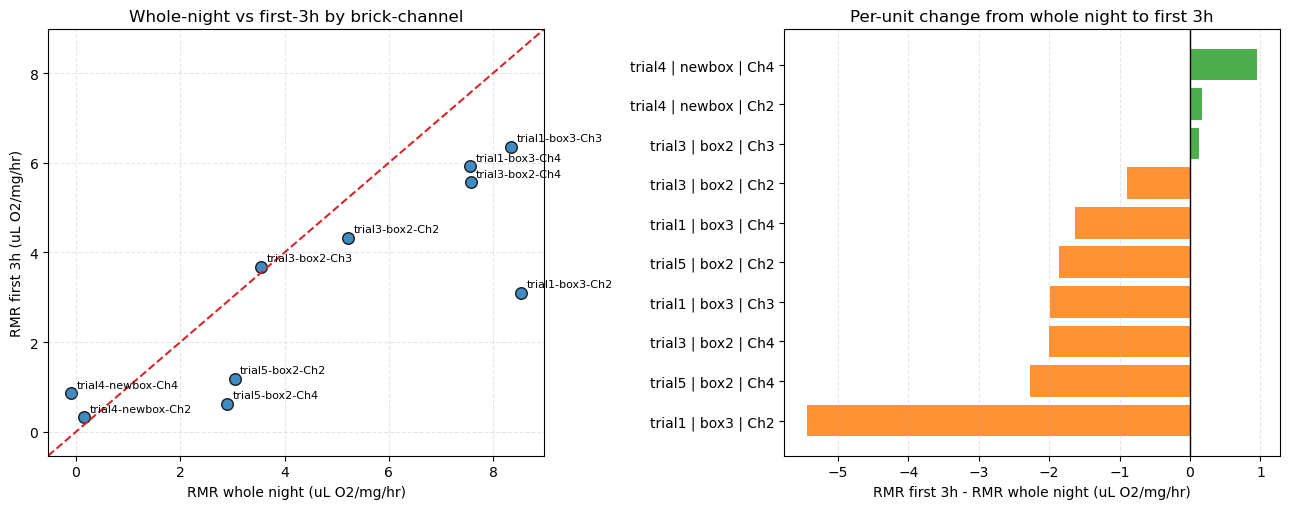

In [9]:
# Brick-channel level comparison: first 3h vs whole-night RMR.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if cyl3h_df.empty:
    print('No restricted data to summarize.')
else:
    key_cols = ['trial', 'brick', 'channel']

    # Treat each brick-channel as the analysis unit.
    first3h_df = cyl3h_df[key_cols + ['RMR']].copy()
    first3h_df = first3h_df.rename(columns={'RMR': 'RMR_first3h'})
    first3h_df['unit'] = first3h_df['trial'] + ' | ' + first3h_df['brick'] + ' | ' + first3h_df['channel']

    print('First 3h RMR by brick-channel unit:')
    display(first3h_df.sort_values(key_cols).reset_index(drop=True))

    whole_night_path = OUT_DIR / 'batch_summary.csv'
    if not whole_night_path.exists():
        raise FileNotFoundError(
            f'Whole-night summary not found at {whole_night_path}. '
            'Run A_batch_respirometry_final.ipynb aggregation first.'
        )

    whole_df = pd.read_csv(whole_night_path)
    whole_df = whole_df[(whole_df['vessel'] == 'cylinder') & (whole_df['environment'] == 'night')].copy()

    whole_df = whole_df[key_cols + ['RMR']].rename(columns={'RMR': 'RMR_whole_night'})
    merged = first3h_df.merge(whole_df, on=key_cols, how='left')
    merged['delta_first3h_minus_whole'] = merged['RMR_first3h'] - merged['RMR_whole_night']
    merged['ratio_first3h_over_whole'] = merged['RMR_first3h'] / merged['RMR_whole_night']

    n_missing = int(merged['RMR_whole_night'].isna().sum())
    print(f'Matched units: {len(merged) - n_missing}/{len(merged)}')
    if n_missing > 0:
        print('Units missing whole-night match:')
        display(merged.loc[merged['RMR_whole_night'].isna(), key_cols + ['RMR_first3h']])

    compare_df = merged.dropna(subset=['RMR_whole_night']).copy()
    compare_df = compare_df.sort_values(key_cols).reset_index(drop=True)

    print('Comparison table (whole night vs first 3h):')
    display(compare_df[['unit', 'RMR_whole_night', 'RMR_first3h', 'delta_first3h_minus_whole', 'ratio_first3h_over_whole']])

    if compare_df.empty:
        print('No matched whole-night rows to plot.')
    else:
        x = compare_df['RMR_whole_night'].to_numpy(dtype=float)
        y = compare_df['RMR_first3h'].to_numpy(dtype=float)

        # Summary metrics for directional shift and agreement.
        mae = float(np.mean(np.abs(y - x)))
        bias = float(np.mean(y - x))
        corr = float(np.corrcoef(x, y)[0, 1]) if len(compare_df) >= 2 else np.nan

        print(f'MAE(first3h vs whole-night): {mae:.3f}')
        print(f'Bias(first3h - whole-night): {bias:.3f}')
        print(f'Pearson r: {corr:.3f}')

        fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

        # Panel 1: whole-night vs first-3h scatter with 1:1 line.
        axes[0].scatter(x, y, s=70, color='#1f77b4', edgecolor='black', alpha=0.85)
        lo = float(min(np.min(x), np.min(y)))
        hi = float(max(np.max(x), np.max(y)))
        pad = 0.05 * (hi - lo + 1e-9)
        axes[0].plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', color='#d62728', linewidth=1.5)
        axes[0].set_xlim(lo - pad, hi + pad)
        axes[0].set_ylim(lo - pad, hi + pad)
        axes[0].set_xlabel('RMR whole night (uL O2/mg/hr)')
        axes[0].set_ylabel('RMR first 3h (uL O2/mg/hr)')
        axes[0].set_title('Whole-night vs first-3h by brick-channel')
        axes[0].grid(True, linestyle='--', alpha=0.3)

        for _, r in compare_df.iterrows():
            short_label = f"{r['trial']}-{r['brick']}-{r['channel']}"
            axes[0].annotate(short_label, (r['RMR_whole_night'], r['RMR_first3h']), fontsize=8, xytext=(4, 4), textcoords='offset points')

        # Panel 2: signed differences by unit.
        diff_df = compare_df.sort_values('delta_first3h_minus_whole')
        y_pos = np.arange(len(diff_df))
        colors = ['#2ca02c' if v >= 0 else '#ff7f0e' for v in diff_df['delta_first3h_minus_whole']]
        axes[1].barh(y_pos, diff_df['delta_first3h_minus_whole'], color=colors, alpha=0.85)
        axes[1].axvline(0.0, color='black', linewidth=1)
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(diff_df['unit'])
        axes[1].set_xlabel('RMR first 3h - RMR whole night (uL O2/mg/hr)')
        axes[1].set_title('Per-unit change from whole night to first 3h')
        axes[1].grid(True, axis='x', linestyle='--', alpha=0.3)

        plt.tight_layout()
        plt.show()

Scenario execution summary:


,scenario,success,n_runs
0,first3h_default,True,4
1,first3h_masked,True,4
2,first3h_no_control,True,4
3,whole_default,True,4
4,whole_masked,True,4
5,whole_no_control,True,4


Sensitivity summary: first3h - whole-night


,mode,n_units,mean_delta,median_delta,mae,frac_positive
0,default,10,-1.485780,-1.747855,1.736326,0.3
1,masked,10,-0.628894,-0.583960,0.846603,0.2
2,no_control,10,-1.988436,-2.180301,2.199816,0.2


Per-unit deltas by mode:


,mode,unit,RMR_whole,RMR_first3h,delta
0,default,trial1 | box3 | Ch2,8.546660,3.103295,-5.443365
1,default,trial5 | box2 | Ch4,2.897411,0.627119,-2.270292
2,default,trial3 | box2 | Ch4,7.572332,5.566268,-2.006063
3,default,trial1 | box3 | Ch3,8.352764,6.357770,-1.994995
4,default,trial5 | box2 | Ch2,3.042832,1.179804,-1.863028
5,default,trial1 | box3 | Ch4,7.555755,5.923074,-1.632681
6,default,trial3 | box2 | Ch2,5.227565,4.327459,-0.900106
7,default,trial3 | box2 | Ch3,3.558230,3.685254,0.127024
8,default,trial4 | newbox | Ch2,0.158096,0.325863,0.167766
9,default,trial4 | newbox | Ch4,-0.103040,0.854903,0.957943


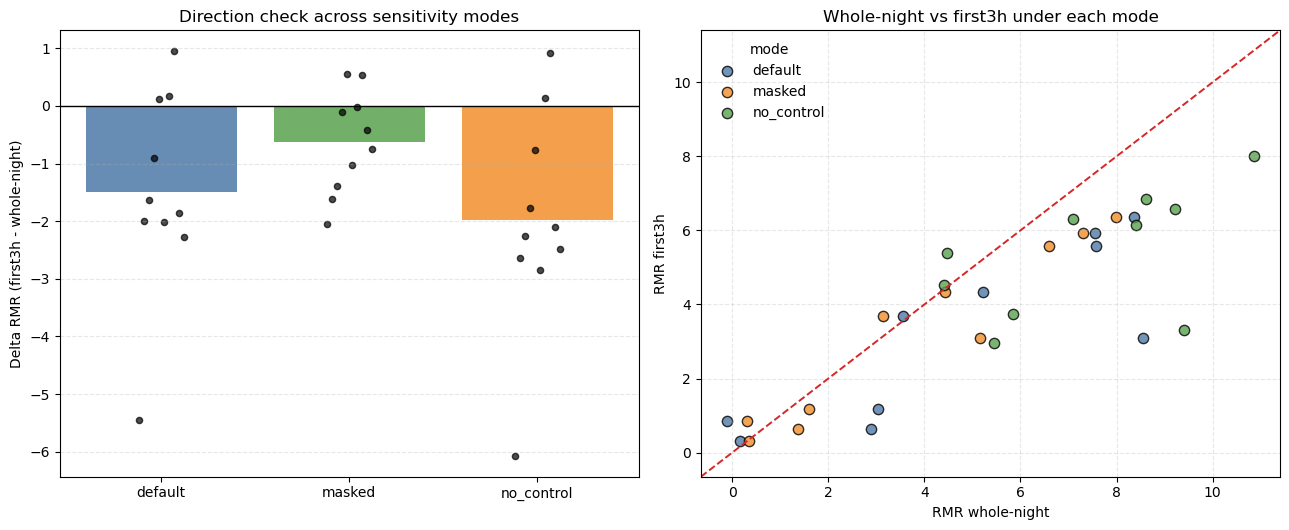

In [10]:
# Sensitivity analysis: identify why first-3h can be lower than whole-night.
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

def collect_rmr_for_scenario(base_runs, *, label, start_hour, end_hour, microbial_cutoff_hour=5, mask_channels=False, debug=False):
    rows = []
    exec_rows = []

    for base_run in base_runs:
        run = copy.deepcopy(base_run)
        run['start_hour'] = start_hour
        run['end_hour'] = end_hour
        run['microbial_cutoff_hour'] = microbial_cutoff_hour
        run['mask_channels'] = bool(mask_channels)
        run['debug'] = bool(debug)

        success, message = run_respirometry_analysis(run)
        exec_rows.append({
            'scenario': label,
            'trial': run['trial'],
            'brick': run['brick'],
            'success': bool(success),
            'message': message,
        })

        if not success:
            continue

        summary_path = OUT_DIR / f"{run['csv'].name}_R_summary.csv"
        if not summary_path.exists():
            exec_rows.append({
                'scenario': label,
                'trial': run['trial'],
                'brick': run['brick'],
                'success': False,
                'message': f'Missing summary file: {summary_path.name}',
            })
            continue

        r_df = pd.read_csv(summary_path)
        channels = run.get('channels', DEFAULT_CHANNELS)

        for ch in channels:
            col = f'{ch}_uL_mg_hr'
            if col not in r_df.columns:
                continue
            rows.append({
                'scenario': label,
                'trial': run['trial'],
                'brick': run['brick'],
                'channel': ch,
                'RMR': float(r_df[col].iloc[0]),
                'start_hour': start_hour,
                'end_hour': end_hour,
                'microbial_cutoff_hour': microbial_cutoff_hour,
                'mask_channels': bool(mask_channels),
            })

    return pd.DataFrame(rows), pd.DataFrame(exec_rows)

scenarios = [
    {'label': 'first3h_default',     'start_hour': 1, 'end_hour': 3, 'microbial_cutoff_hour': 5, 'mask_channels': False},
    {'label': 'whole_default',       'start_hour': 1, 'end_hour': 8, 'microbial_cutoff_hour': 5, 'mask_channels': False},
    {'label': 'first3h_no_control',  'start_hour': 1, 'end_hour': 3, 'microbial_cutoff_hour': 0, 'mask_channels': False},
    {'label': 'whole_no_control',    'start_hour': 1, 'end_hour': 8, 'microbial_cutoff_hour': 0, 'mask_channels': False},
    {'label': 'first3h_masked',      'start_hour': 1, 'end_hour': 3, 'microbial_cutoff_hour': 5, 'mask_channels': True},
    {'label': 'whole_masked',        'start_hour': 1, 'end_hour': 8, 'microbial_cutoff_hour': 5, 'mask_channels': True},
]

scenario_frames = []
scenario_exec_frames = []
for s in scenarios:
    df_s, exec_s = collect_rmr_for_scenario(restricted_runs, **s)
    scenario_frames.append(df_s)
    scenario_exec_frames.append(exec_s)

scenario_rmr_df = pd.concat(scenario_frames, ignore_index=True)
scenario_exec_df = pd.concat(scenario_exec_frames, ignore_index=True)

print('Scenario execution summary:')
display(scenario_exec_df.groupby(['scenario', 'success']).size().reset_index(name='n_runs'))

pair_specs = [
    ('default', 'whole_default', 'first3h_default'),
    ('no_control', 'whole_no_control', 'first3h_no_control'),
    ('masked', 'whole_masked', 'first3h_masked'),
]

pair_rows = []
for mode, whole_label, first_label in pair_specs:
    whole = scenario_rmr_df[scenario_rmr_df['scenario'] == whole_label][['trial', 'brick', 'channel', 'RMR']].rename(columns={'RMR': 'RMR_whole'})
    first = scenario_rmr_df[scenario_rmr_df['scenario'] == first_label][['trial', 'brick', 'channel', 'RMR']].rename(columns={'RMR': 'RMR_first3h'})
    merged = whole.merge(first, on=['trial', 'brick', 'channel'], how='inner')
    if merged.empty:
        continue
    merged['delta'] = merged['RMR_first3h'] - merged['RMR_whole']
    merged['mode'] = mode
    pair_rows.append(merged)

if not pair_rows:
    raise ValueError('No paired scenario comparisons were produced.')

sensitivity_compare_df = pd.concat(pair_rows, ignore_index=True)
sensitivity_compare_df['unit'] = sensitivity_compare_df['trial'] + ' | ' + sensitivity_compare_df['brick'] + ' | ' + sensitivity_compare_df['channel']

summary = sensitivity_compare_df.groupby('mode').agg(
    n_units=('delta', 'size'),
    mean_delta=('delta', 'mean'),
    median_delta=('delta', 'median'),
    mae=('delta', lambda x: float(np.mean(np.abs(x)))),
    frac_positive=('delta', lambda x: float(np.mean(x > 0))),
).reset_index()

print('Sensitivity summary: first3h - whole-night')
display(summary)

print('Per-unit deltas by mode:')
display(
    sensitivity_compare_df[['mode', 'unit', 'RMR_whole', 'RMR_first3h', 'delta']]
    .sort_values(['mode', 'delta'])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# Panel 1: mean delta by mode with individual points.
modes = list(summary['mode'])
x_pos = np.arange(len(modes))
means = summary['mean_delta'].to_numpy(dtype=float)
axes[0].bar(x_pos, means, color=['#4e79a7', '#59a14f', '#f28e2b'], alpha=0.85)
for i, mode in enumerate(modes):
    vals = sensitivity_compare_df.loc[sensitivity_compare_df['mode'] == mode, 'delta'].to_numpy(dtype=float)
    jitter = np.linspace(-0.12, 0.12, len(vals)) if len(vals) > 1 else np.array([0.0])
    axes[0].scatter(np.full_like(vals, i, dtype=float) + jitter, vals, color='black', s=20, alpha=0.7)
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(modes)
axes[0].set_ylabel('Delta RMR (first3h - whole-night)')
axes[0].set_title('Direction check across sensitivity modes')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# Panel 2: whole vs first3h scatter by mode.
palette = {'default': '#4e79a7', 'no_control': '#59a14f', 'masked': '#f28e2b'}
for mode in modes:
    d = sensitivity_compare_df[sensitivity_compare_df['mode'] == mode]
    axes[1].scatter(d['RMR_whole'], d['RMR_first3h'], s=55, alpha=0.8, label=mode, color=palette.get(mode, '#333333'), edgecolor='black')

all_vals = np.concatenate([sensitivity_compare_df['RMR_whole'].to_numpy(dtype=float), sensitivity_compare_df['RMR_first3h'].to_numpy(dtype=float)])
lo = float(np.min(all_vals))
hi = float(np.max(all_vals))
pad = 0.05 * (hi - lo + 1e-9)
axes[1].plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', color='#d62728', linewidth=1.4)
axes[1].set_xlim(lo - pad, hi + pad)
axes[1].set_ylim(lo - pad, hi + pad)
axes[1].set_xlabel('RMR whole-night')
axes[1].set_ylabel('RMR first3h')
axes[1].set_title('Whole-night vs first3h under each mode')
axes[1].legend(frameon=False, title='mode')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Debug scenario execution summary:


,scenario,success,n_runs
0,first3h_default_dbg,True,4
1,first3h_masked_dbg,True,4
2,whole_default_dbg,True,4
3,whole_masked_dbg,True,4


Debug summary (first3h - whole-night):


,mode,n_units,mean_delta_slope,mean_delta_mo2_corr,frac_delta_mo2_corr_positive
0,default,10,0.003192,-0.377404,0.3
1,masked,10,0.001877,-0.172906,0.2


Per-unit debug comparison:


,mode,unit,slope_whole,slope_first3h,delta_slope_first_minus_whole,mo2_raw_whole,mo2_raw_first3h,mo2_ctrl_whole,mo2_ctrl_first3h,mo2_corr_whole,mo2_corr_first3h,delta_mo2_corr_first_minus_whole,n_used_whole,n_used_first3h
0,default,trial1 | box3 | Ch2,-0.017912,-0.006339,0.011574,2.747939,0.970013,0.249750,0.063452,2.498189,0.906561,-1.591627,12101,3458
1,default,trial1 | box3 | Ch3,-0.017643,-0.012621,0.005021,2.685909,1.916666,0.249750,0.063452,2.436159,1.853214,-0.582945,12101,3458
2,default,trial1 | box3 | Ch4,-0.016465,-0.012055,0.004411,2.487358,1.816519,0.249750,0.063452,2.237607,1.753067,-0.484540,12101,3458
3,default,trial5 | box2 | Ch4,-0.006612,-0.003603,0.003008,1.063673,0.578669,0.498803,0.456456,0.564870,0.122213,-0.442657,5041,1441
4,default,trial3 | box2 | Ch4,-0.013900,-0.010245,0.003655,2.228136,1.645214,0.673519,0.501975,1.554616,1.143239,-0.411377,5041,1441
5,default,trial5 | box2 | Ch2,-0.006629,-0.004250,0.002379,1.042588,0.667216,0.498803,0.456456,0.543786,0.210760,-0.333026,5041,1441
6,default,trial3 | box2 | Ch2,-0.010931,-0.008681,0.002250,1.713055,1.362874,0.673519,0.501975,1.039536,0.860900,-0.178637,5041,1441
7,default,trial3 | box2 | Ch3,-0.008563,-0.007618,0.000945,1.352216,1.205191,0.673519,0.501975,0.678697,0.703216,0.024519,5041,1441
8,default,trial4 | newbox | Ch2,-0.006060,-0.006242,-0.000182,0.943817,0.972867,0.909898,0.902943,0.033919,0.069924,0.036005,5040,1440
9,default,trial4 | newbox | Ch4,-0.005583,-0.006729,-0.001146,0.889436,1.072733,0.909898,0.902943,-0.020461,0.169790,0.190251,5040,1440


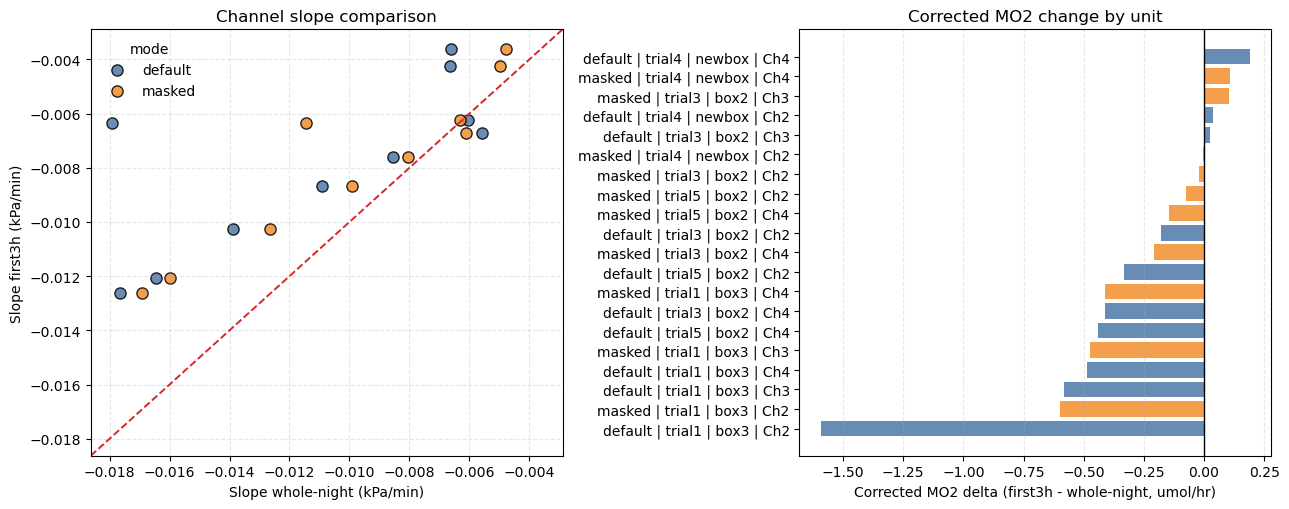

In [11]:
# Debug diagnostics: compare fitted slopes and control terms (first3h vs whole-night).
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

def run_debug_scenario(base_runs, *, label, start_hour, end_hour, microbial_cutoff_hour=5, mask_channels=False):
    debug_rows = []
    exec_rows = []

    for base_run in base_runs:
        run = copy.deepcopy(base_run)
        run['start_hour'] = start_hour
        run['end_hour'] = end_hour
        run['microbial_cutoff_hour'] = microbial_cutoff_hour
        run['mask_channels'] = bool(mask_channels)
        run['debug'] = True

        success, message = run_respirometry_analysis(run)
        exec_rows.append({
            'scenario': label,
            'trial': run['trial'],
            'brick': run['brick'],
            'success': bool(success),
            'message': message,
        })

        if not success:
            continue

        dbg_path = OUT_DIR / f"{run['csv'].name}_R_debug.csv"
        if not dbg_path.exists():
            exec_rows.append({
                'scenario': label,
                'trial': run['trial'],
                'brick': run['brick'],
                'success': False,
                'message': f'Missing debug file: {dbg_path.name}',
            })
            continue

        d = pd.read_csv(dbg_path)
        d['scenario'] = label
        d['trial'] = run['trial']
        d['brick'] = run['brick']
        d['csv'] = run['csv'].name
        debug_rows.append(d)

    debug_df = pd.concat(debug_rows, ignore_index=True) if debug_rows else pd.DataFrame()
    exec_df = pd.DataFrame(exec_rows)
    return debug_df, exec_df

debug_scenarios = [
    {'label': 'first3h_default_dbg', 'start_hour': 1, 'end_hour': 3, 'microbial_cutoff_hour': 5, 'mask_channels': False},
    {'label': 'whole_default_dbg',   'start_hour': 1, 'end_hour': 8, 'microbial_cutoff_hour': 5, 'mask_channels': False},
    {'label': 'first3h_masked_dbg',  'start_hour': 1, 'end_hour': 3, 'microbial_cutoff_hour': 5, 'mask_channels': True},
    {'label': 'whole_masked_dbg',    'start_hour': 1, 'end_hour': 8, 'microbial_cutoff_hour': 5, 'mask_channels': True},
]

dbg_frames = []
dbg_exec_frames = []
for s in debug_scenarios:
    d_df, e_df = run_debug_scenario(restricted_runs, **s)
    dbg_frames.append(d_df)
    dbg_exec_frames.append(e_df)

debug_raw_df = pd.concat([d for d in dbg_frames if not d.empty], ignore_index=True)
debug_exec_df = pd.concat(dbg_exec_frames, ignore_index=True)

print('Debug scenario execution summary:')
display(debug_exec_df.groupby(['scenario', 'success']).size().reset_index(name='n_runs'))

if debug_raw_df.empty:
    raise ValueError('No debug rows collected.')

# Keep only channel rows for channel-vs-channel comparisons.
ch_dbg = debug_raw_df[debug_raw_df['role'] == 'channel'].copy()
ch_dbg = ch_dbg.rename(columns={'entity': 'channel'})

pair_map = [
    ('default', 'whole_default_dbg', 'first3h_default_dbg'),
    ('masked', 'whole_masked_dbg', 'first3h_masked_dbg'),
]

paired_rows = []
for mode, whole_label, first_label in pair_map:
    w = ch_dbg[ch_dbg['scenario'] == whole_label].copy()
    f = ch_dbg[ch_dbg['scenario'] == first_label].copy()

    keep_cols = [
        'trial', 'brick', 'channel',
        'slope_kpa_per_min',
        'MO2_raw_umol_per_hr',
        'MO2_control_umol_per_hr',
        'MO2_corrected_umol_per_hr',
        'n_used',
        'used_hour_min',
        'used_hour_max',
    ]
    w = w[keep_cols].rename(columns={
        'slope_kpa_per_min': 'slope_whole',
        'MO2_raw_umol_per_hr': 'mo2_raw_whole',
        'MO2_control_umol_per_hr': 'mo2_ctrl_whole',
        'MO2_corrected_umol_per_hr': 'mo2_corr_whole',
        'n_used': 'n_used_whole',
        'used_hour_min': 'used_hour_min_whole',
        'used_hour_max': 'used_hour_max_whole',
    })
    f = f[keep_cols].rename(columns={
        'slope_kpa_per_min': 'slope_first3h',
        'MO2_raw_umol_per_hr': 'mo2_raw_first3h',
        'MO2_control_umol_per_hr': 'mo2_ctrl_first3h',
        'MO2_corrected_umol_per_hr': 'mo2_corr_first3h',
        'n_used': 'n_used_first3h',
        'used_hour_min': 'used_hour_min_first3h',
        'used_hour_max': 'used_hour_max_first3h',
    })

    m = w.merge(f, on=['trial', 'brick', 'channel'], how='inner')
    if m.empty:
        continue
    m['mode'] = mode
    m['unit'] = m['trial'] + ' | ' + m['brick'] + ' | ' + m['channel']
    m['delta_slope_first_minus_whole'] = m['slope_first3h'] - m['slope_whole']
    m['delta_mo2_corr_first_minus_whole'] = m['mo2_corr_first3h'] - m['mo2_corr_whole']
    paired_rows.append(m)

if not paired_rows:
    raise ValueError('No paired debug comparisons available.')

debug_compare_df = pd.concat(paired_rows, ignore_index=True)

summary_debug = debug_compare_df.groupby('mode').agg(
    n_units=('unit', 'size'),
    mean_delta_slope=('delta_slope_first_minus_whole', 'mean'),
    mean_delta_mo2_corr=('delta_mo2_corr_first_minus_whole', 'mean'),
    frac_delta_mo2_corr_positive=('delta_mo2_corr_first_minus_whole', lambda x: float(np.mean(x > 0))),
).reset_index()

print('Debug summary (first3h - whole-night):')
display(summary_debug)

print('Per-unit debug comparison:')
display(
    debug_compare_df[[
        'mode', 'unit',
        'slope_whole', 'slope_first3h', 'delta_slope_first_minus_whole',
        'mo2_raw_whole', 'mo2_raw_first3h',
        'mo2_ctrl_whole', 'mo2_ctrl_first3h',
        'mo2_corr_whole', 'mo2_corr_first3h', 'delta_mo2_corr_first_minus_whole',
        'n_used_whole', 'n_used_first3h',
    ]].sort_values(['mode', 'delta_mo2_corr_first_minus_whole']).reset_index(drop=True)
 )

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: slope comparison.
palette = {'default': '#4e79a7', 'masked': '#f28e2b'}
for mode in sorted(debug_compare_df['mode'].unique()):
    dm = debug_compare_df[debug_compare_df['mode'] == mode]
    axes[0].scatter(dm['slope_whole'], dm['slope_first3h'], s=65, color=palette.get(mode, '#333333'), edgecolor='black', alpha=0.85, label=mode)

slope_vals = np.concatenate([debug_compare_df['slope_whole'].to_numpy(dtype=float), debug_compare_df['slope_first3h'].to_numpy(dtype=float)])
lo = float(np.min(slope_vals))
hi = float(np.max(slope_vals))
pad = 0.05 * (hi - lo + 1e-9)
axes[0].plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', color='#d62728', linewidth=1.4)
axes[0].set_xlim(lo - pad, hi + pad)
axes[0].set_ylim(lo - pad, hi + pad)
axes[0].set_xlabel('Slope whole-night (kPa/min)')
axes[0].set_ylabel('Slope first3h (kPa/min)')
axes[0].set_title('Channel slope comparison')
axes[0].legend(frameon=False, title='mode')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel 2: corrected MO2 deltas by unit.
plot_df = debug_compare_df.sort_values('delta_mo2_corr_first_minus_whole').copy()
plot_df['label'] = plot_df['mode'] + ' | ' + plot_df['unit']
y_pos = np.arange(len(plot_df))
bar_colors = [palette.get(m, '#333333') for m in plot_df['mode']]
axes[1].barh(y_pos, plot_df['delta_mo2_corr_first_minus_whole'], color=bar_colors, alpha=0.85)
axes[1].axvline(0.0, color='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(plot_df['label'])
axes[1].set_xlabel('Corrected MO2 delta (first3h - whole-night, umol/hr)')
axes[1].set_title('Corrected MO2 change by unit')
axes[1].grid(True, axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Trial 1 decomposition (default mode):


,unit,mo2_raw_whole,mo2_raw_first3h,raw_delta,mo2_ctrl_whole,mo2_ctrl_first3h,ctrl_delta,mo2_corr_whole,mo2_corr_first3h,corr_delta,slope_whole,slope_first3h,delta_slope_first_minus_whole
0,trial1 | box3 | Ch2,2.747939,0.970013,-1.777926,0.24975,0.063452,-0.186298,2.498189,0.906561,-1.591627,-0.017912,-0.006339,0.011574
1,trial1 | box3 | Ch3,2.685909,1.916666,-0.769243,0.24975,0.063452,-0.186298,2.436159,1.853214,-0.582945,-0.017643,-0.012621,0.005021
2,trial1 | box3 | Ch4,2.487358,1.816519,-0.670839,0.24975,0.063452,-0.186298,2.237607,1.753067,-0.484540,-0.016465,-0.012055,0.004411


Start-time sensitivity summary (default settings):


,start_hour,status,n_pairs,mean_delta_all,mean_delta_trial1
0,1.00,ok,10,-1.485780,-3.023680
1,1.25,ok,10,-1.421389,-2.821852
2,1.50,ok,10,-1.336342,-2.632922


Per-unit deltas across start times:


,start_hour,unit,RMR_whole,RMR_first3h,delta
0,1.00,trial1 | box3 | Ch2,8.546660,3.103295,-5.443365
1,1.00,trial5 | box2 | Ch4,2.897411,0.627119,-2.270292
2,1.00,trial3 | box2 | Ch4,7.572332,5.566268,-2.006063
3,1.00,trial1 | box3 | Ch3,8.352764,6.357770,-1.994995
4,1.00,trial5 | box2 | Ch2,3.042832,1.179804,-1.863028
5,1.00,trial1 | box3 | Ch4,7.555755,5.923074,-1.632681
6,1.00,trial3 | box2 | Ch2,5.227565,4.327459,-0.900106
7,1.00,trial3 | box2 | Ch3,3.558230,3.685254,0.127024
8,1.00,trial4 | newbox | Ch2,0.158096,0.325863,0.167766
9,1.00,trial4 | newbox | Ch4,-0.103040,0.854903,0.957943


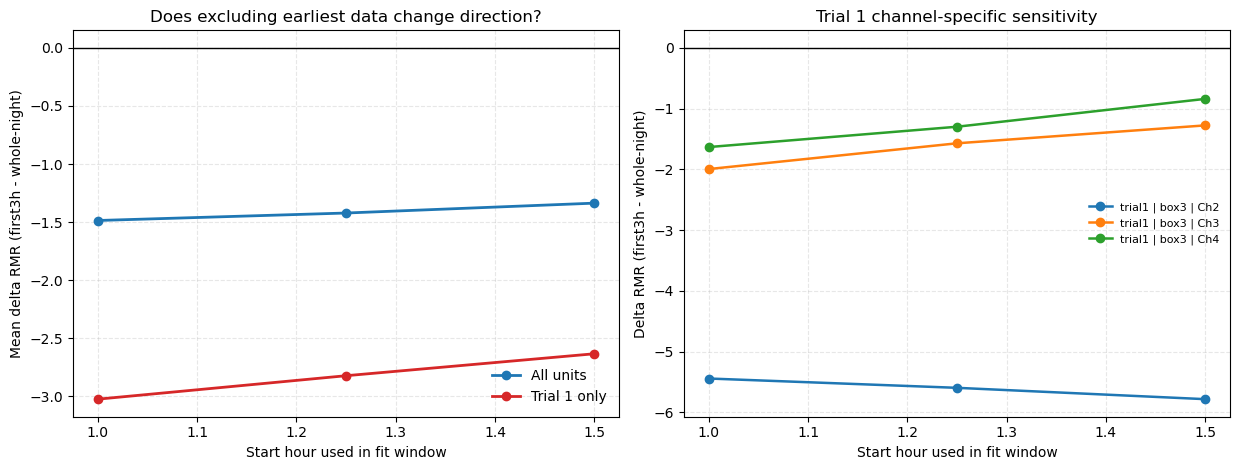

In [12]:
# Trial 1 deep dive + start-time sensitivity (exclude first 15-30 min).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'collect_rmr_for_scenario' not in globals() or 'debug_compare_df' not in globals():
    raise ValueError('Run Cells 8-9 first to populate sensitivity/debug helpers.')

# -----------------------------------------------------------------------------
# Part A: Trial 1 decomposition from debug outputs (default mode).
# -----------------------------------------------------------------------------
trial1_dbg = debug_compare_df[(debug_compare_df['trial'] == 'trial1') & (debug_compare_df['mode'] == 'default')].copy()

if trial1_dbg.empty:
    print('No Trial 1 debug rows found in default mode.')
else:
    trial1_dbg = trial1_dbg.sort_values(['brick', 'channel']).reset_index(drop=True)
    trial1_dbg['raw_delta'] = trial1_dbg['mo2_raw_first3h'] - trial1_dbg['mo2_raw_whole']
    trial1_dbg['ctrl_delta'] = trial1_dbg['mo2_ctrl_first3h'] - trial1_dbg['mo2_ctrl_whole']
    trial1_dbg['corr_delta'] = trial1_dbg['mo2_corr_first3h'] - trial1_dbg['mo2_corr_whole']

    print('Trial 1 decomposition (default mode):')
    display(
        trial1_dbg[[
            'unit',
            'mo2_raw_whole', 'mo2_raw_first3h', 'raw_delta',
            'mo2_ctrl_whole', 'mo2_ctrl_first3h', 'ctrl_delta',
            'mo2_corr_whole', 'mo2_corr_first3h', 'corr_delta',
            'slope_whole', 'slope_first3h', 'delta_slope_first_minus_whole',
        ]]
    )

# -----------------------------------------------------------------------------
# Part B: Start-time sensitivity (1.00, 1.25, 1.50 h).
# -----------------------------------------------------------------------------
start_hours = [1.00, 1.25, 1.50]
window_rows = []
unit_rows = []

for sh in start_hours:
    label_first = f'first3h_start_{sh:.2f}'
    label_whole = f'whole_start_{sh:.2f}'

    df_first, exec_first = collect_rmr_for_scenario(
        restricted_runs,
        label=label_first,
        start_hour=sh,
        end_hour=3,
        microbial_cutoff_hour=5,
        mask_channels=False,
        debug=False,
    )
    df_whole, exec_whole = collect_rmr_for_scenario(
        restricted_runs,
        label=label_whole,
        start_hour=sh,
        end_hour=8,
        microbial_cutoff_hour=5,
        mask_channels=False,
        debug=False,
    )

    exec_pair = pd.concat([exec_first, exec_whole], ignore_index=True)
    ok = bool(exec_pair['success'].all())

    if not ok or df_first.empty or df_whole.empty:
        window_rows.append({
            'start_hour': sh,
            'status': 'failed',
            'n_pairs': 0,
            'mean_delta_all': np.nan,
            'mean_delta_trial1': np.nan,
        })
        continue

    m_first = df_first[['trial', 'brick', 'channel', 'RMR']].rename(columns={'RMR': 'RMR_first3h'})
    m_whole = df_whole[['trial', 'brick', 'channel', 'RMR']].rename(columns={'RMR': 'RMR_whole'})
    m = m_whole.merge(m_first, on=['trial', 'brick', 'channel'], how='inner')
    m['delta'] = m['RMR_first3h'] - m['RMR_whole']
    m['start_hour'] = sh
    m['unit'] = m['trial'] + ' | ' + m['brick'] + ' | ' + m['channel']

    unit_rows.append(m)

    trial1_mask = m['trial'].eq('trial1')
    window_rows.append({
        'start_hour': sh,
        'status': 'ok',
        'n_pairs': int(len(m)),
        'mean_delta_all': float(m['delta'].mean()),
        'mean_delta_trial1': float(m.loc[trial1_mask, 'delta'].mean()) if trial1_mask.any() else np.nan,
    })

window_summary_df = pd.DataFrame(window_rows).sort_values('start_hour').reset_index(drop=True)
window_units_df = pd.concat(unit_rows, ignore_index=True) if unit_rows else pd.DataFrame()

print('Start-time sensitivity summary (default settings):')
display(window_summary_df)

if not window_units_df.empty:
    print('Per-unit deltas across start times:')
    display(
        window_units_df[['start_hour', 'unit', 'RMR_whole', 'RMR_first3h', 'delta']]
        .sort_values(['start_hour', 'delta'])
        .reset_index(drop=True)
    )

    # Plot mean deltas as start hour shifts later.
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

    axes[0].plot(window_summary_df['start_hour'], window_summary_df['mean_delta_all'], marker='o', linewidth=2, color='#1f77b4', label='All units')
    axes[0].plot(window_summary_df['start_hour'], window_summary_df['mean_delta_trial1'], marker='o', linewidth=2, color='#d62728', label='Trial 1 only')
    axes[0].axhline(0.0, color='black', linewidth=1)
    axes[0].set_xlabel('Start hour used in fit window')
    axes[0].set_ylabel('Mean delta RMR (first3h - whole-night)')
    axes[0].set_title('Does excluding earliest data change direction?')
    axes[0].grid(True, linestyle='--', alpha=0.3)
    axes[0].legend(frameon=False)

    # Trial 1 channel-level lines.
    t1 = window_units_df[window_units_df['trial'] == 'trial1'].copy()
    for unit, g in t1.groupby('unit'):
        g = g.sort_values('start_hour')
        axes[1].plot(g['start_hour'], g['delta'], marker='o', linewidth=1.8, label=unit)
    axes[1].axhline(0.0, color='black', linewidth=1)
    axes[1].set_xlabel('Start hour used in fit window')
    axes[1].set_ylabel('Delta RMR (first3h - whole-night)')
    axes[1].set_title('Trial 1 channel-specific sensitivity')
    axes[1].grid(True, linestyle='--', alpha=0.3)
    axes[1].legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('No successful start-time sensitivity results to plot.')

Control fit diagnostics (linear vs quadratic):


,trial,brick,window,slope_linear,slope_quad_mean,slope_quad_start,slope_quad_end,r2_linear,r2_quad,rmse_linear,rmse_quad,rmse_gain_quad_vs_lin,delta_slope_quadmean_minus_linear
0,trial1,box3,1-3h,-0.072235,-0.072228,0.139688,-0.284144,0.031897,0.050208,0.229810,0.227626,0.002184,7.182398e-06
1,trial1,box3,1-8h,-2.644310,-2.644244,1.895619,-7.184106,0.831687,0.995137,2.403790,0.408576,1.995213,6.632307e-05
2,trial3,box2,1-3h,-2.075839,-2.075839,-1.622424,-2.529253,0.888058,0.890887,0.425804,0.420390,0.005414,-5.240253e-14
3,trial3,box2,1-8h,-3.100893,-3.100893,-2.341671,-3.860115,0.990469,0.994429,0.614777,0.470014,0.144764,1.243450e-14
4,trial4,newbox,1-3h,-3.538689,-3.538689,-3.606999,-3.470379,0.844227,0.844248,0.877647,0.877588,0.000059,-2.845515e-08
5,trial4,newbox,1-8h,-3.657232,-3.657232,-3.461986,-3.852478,0.988739,0.988927,0.788735,0.782126,0.006609,-5.166149e-08
6,trial5,box2,1-3h,-1.593864,-1.593864,-1.262656,-1.925072,0.832097,0.834496,0.413651,0.410686,0.002965,-3.907985e-14
7,trial5,box2,1-8h,-2.655053,-2.655053,-0.744129,-4.565978,0.959971,0.993136,1.095788,0.453770,0.642018,2.220446e-14


Trial 4 corrected-slope proxy sensitivity (linear vs quadratic control):


,trial,brick,channel,window,corr_proxy_linear,corr_proxy_quadmean,delta_corr_proxy_quad_minus_linear,slope_linear,slope_quad_mean,r2_linear,r2_quad
0,trial4,newbox,Ch2,1-3h,-0.239280,-0.239280,-2.379720e-08,-3.777969,-3.777969,0.927127,0.927196
1,trial4,newbox,Ch4,1-3h,-0.529696,-0.529696,-1.762322e-07,-4.068385,-4.068385,0.918995,0.919890
2,trial4,newbox,Ch2,1-8h,0.018791,0.018791,1.527741e-07,-3.638441,-3.638441,0.993797,0.994528
3,trial4,newbox,Ch4,1-8h,0.301741,0.301741,2.322176e-07,-3.355491,-3.355491,0.988880,0.991607


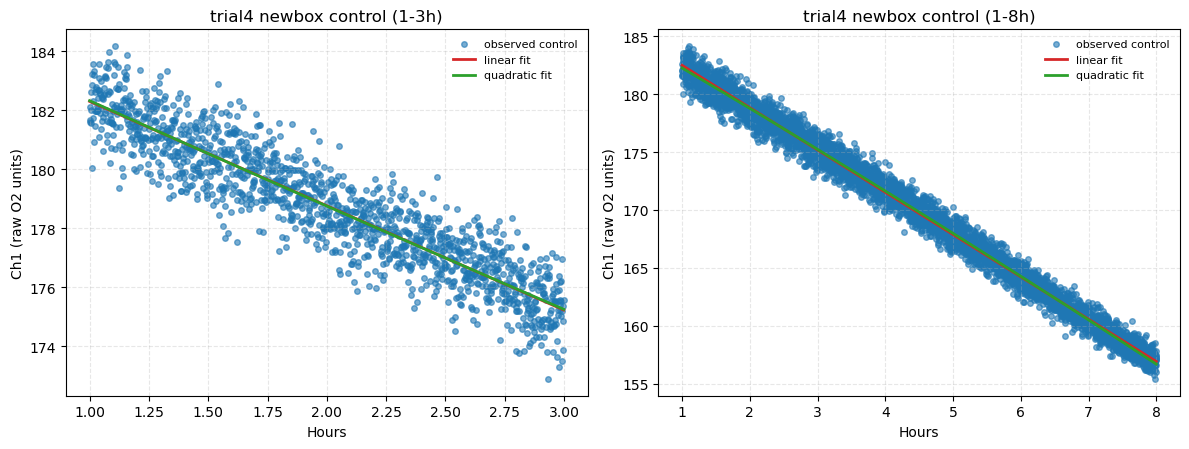

In [13]:
# Control nonlinearity diagnostic: linear vs quadratic background fits.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

def fit_linear_and_quadratic(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 5:
        return None

    p1 = np.polyfit(x, y, 1)
    p2 = np.polyfit(x, y, 2)

    y1 = np.polyval(p1, x)
    y2 = np.polyval(p2, x)

    def r2(obs, pred):
        ss_res = float(np.sum((obs - pred) ** 2))
        ss_tot = float(np.sum((obs - np.mean(obs)) ** 2))
        return np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot

    rmse1 = float(np.sqrt(np.mean((y - y1) ** 2)))
    rmse2 = float(np.sqrt(np.mean((y - y2) ** 2)))
    r2_1 = r2(y, y1)
    r2_2 = r2(y, y2)

    x_min = float(np.min(x))
    x_max = float(np.max(x))
    x_mid = 0.5 * (x_min + x_max)

    # Slopes in units of channel per hour.
    slope_lin = float(p1[0])
    slope_q_start = float(2 * p2[0] * x_min + p2[1])
    slope_q_mid = float(2 * p2[0] * x_mid + p2[1])
    slope_q_end = float(2 * p2[0] * x_max + p2[1])
    slope_q_mean = float((np.polyval(p2, x_max) - np.polyval(p2, x_min)) / (x_max - x_min))

    return {
        'p1': p1,
        'p2': p2,
        'rmse_lin': rmse1,
        'rmse_quad': rmse2,
        'r2_lin': r2_1,
        'r2_quad': r2_2,
        'slope_lin': slope_lin,
        'slope_q_start': slope_q_start,
        'slope_q_mid': slope_q_mid,
        'slope_q_end': slope_q_end,
        'slope_q_mean': slope_q_mean,
    }

def compute_window_diagnostics(run, start_hour, end_hour):
    csv_path = run['csv']
    if not csv_path.exists():
        return pd.DataFrame(), None

    df = pd.read_csv(csv_path)
    if 'hours' not in df.columns:
        return pd.DataFrame(), None

    control_ch = run.get('control', 'Ch1')
    channels = run.get('channels', DEFAULT_CHANNELS)
    if control_ch not in df.columns:
        return pd.DataFrame(), None

    win = df[(df['hours'] >= start_hour) & (df['hours'] <= end_hour)].copy()
    win = win.dropna(subset=['hours', control_ch])
    if len(win) < 5:
        return pd.DataFrame(), None

    rows = []
    x = win['hours'].to_numpy(dtype=float)

    # Control model fit quality and implied slopes.
    fit_ctrl = fit_linear_and_quadratic(x, win[control_ch].to_numpy(dtype=float))
    if fit_ctrl is None:
        return pd.DataFrame(), None

    rows.append({
        'trial': run['trial'],
        'brick': run['brick'],
        'channel': control_ch,
        'role': 'control',
        'window': f'{start_hour}-{end_hour}h',
        'slope_linear': fit_ctrl['slope_lin'],
        'slope_quad_mean': fit_ctrl['slope_q_mean'],
        'slope_quad_start': fit_ctrl['slope_q_start'],
        'slope_quad_mid': fit_ctrl['slope_q_mid'],
        'slope_quad_end': fit_ctrl['slope_q_end'],
        'rmse_linear': fit_ctrl['rmse_lin'],
        'rmse_quad': fit_ctrl['rmse_quad'],
        'r2_linear': fit_ctrl['r2_lin'],
        'r2_quad': fit_ctrl['r2_quad'],
    })

    # Channel-level corrected slope proxies (channel slope - control slope).
    for ch in channels:
        if ch not in win.columns:
            continue
        y = win[ch].to_numpy(dtype=float)
        fit_ch = fit_linear_and_quadratic(x, y)
        if fit_ch is None:
            continue

        rows.append({
            'trial': run['trial'],
            'brick': run['brick'],
            'channel': ch,
            'role': 'channel',
            'window': f'{start_hour}-{end_hour}h',
            'slope_linear': fit_ch['slope_lin'],
            'slope_quad_mean': fit_ch['slope_q_mean'],
            'slope_quad_start': fit_ch['slope_q_start'],
            'slope_quad_mid': fit_ch['slope_q_mid'],
            'slope_quad_end': fit_ch['slope_q_end'],
            'rmse_linear': fit_ch['rmse_lin'],
            'rmse_quad': fit_ch['rmse_quad'],
            'r2_linear': fit_ch['r2_lin'],
            'r2_quad': fit_ch['r2_quad'],
            'corr_proxy_linear': fit_ch['slope_lin'] - fit_ctrl['slope_lin'],
            'corr_proxy_quadmean': fit_ch['slope_q_mean'] - fit_ctrl['slope_q_mean'],
        })

    plot_payload = {
        'x': x,
        'y_ctrl': win[control_ch].to_numpy(dtype=float),
        'fit_ctrl': fit_ctrl,
        'control_ch': control_ch,
    }
    return pd.DataFrame(rows), plot_payload

# Focus on restricted cylinder-night runs; highlight trial4.
target_runs = [r for r in restricted_runs if r.get('metadata', {}).get('environment') == 'night']
diag_frames = []
plot_payloads = []

for run in target_runs:
    for sh, eh in [(1, 3), (1, 8)]:
        ddf, payload = compute_window_diagnostics(run, sh, eh)
        if not ddf.empty:
            diag_frames.append(ddf)
            payload['trial'] = run['trial']
            payload['brick'] = run['brick']
            payload['window'] = f'{sh}-{eh}h'
            plot_payloads.append(payload)

if not diag_frames:
    raise ValueError('No diagnostics produced. Check window/channel availability.')

nonlin_diag_df = pd.concat(diag_frames, ignore_index=True)

# Control-only summary: does quadratic fit improve and does implied slope differ?
control_summary = nonlin_diag_df[nonlin_diag_df['role'] == 'control'].copy()
control_summary['rmse_gain_quad_vs_lin'] = control_summary['rmse_linear'] - control_summary['rmse_quad']
control_summary['delta_slope_quadmean_minus_linear'] = control_summary['slope_quad_mean'] - control_summary['slope_linear']
control_summary = control_summary.sort_values(['trial', 'window']).reset_index(drop=True)

print('Control fit diagnostics (linear vs quadratic):')
display(control_summary[[
    'trial', 'brick', 'window',
    'slope_linear', 'slope_quad_mean', 'slope_quad_start', 'slope_quad_end',
    'r2_linear', 'r2_quad', 'rmse_linear', 'rmse_quad',
    'rmse_gain_quad_vs_lin', 'delta_slope_quadmean_minus_linear',
]])

# Channel corrected-proxy comparison for trial4 specifically (where negatives were observed).
trial4_proxy = nonlin_diag_df[(nonlin_diag_df['trial'] == 'trial4') & (nonlin_diag_df['role'] == 'channel')].copy()
if trial4_proxy.empty:
    print('No trial4 channel diagnostics found in restricted runs.')
else:
    trial4_proxy['delta_corr_proxy_quad_minus_linear'] = trial4_proxy['corr_proxy_quadmean'] - trial4_proxy['corr_proxy_linear']
    print('Trial 4 corrected-slope proxy sensitivity (linear vs quadratic control):')
    display(trial4_proxy[[
        'trial', 'brick', 'channel', 'window',
        'corr_proxy_linear', 'corr_proxy_quadmean', 'delta_corr_proxy_quad_minus_linear',
        'slope_linear', 'slope_quad_mean', 'r2_linear', 'r2_quad',
]].sort_values(['window', 'channel']).reset_index(drop=True))

# Visualize control curvature for trial4 (if present).
trial4_plots = [p for p in plot_payloads if p['trial'] == 'trial4']
if trial4_plots:
    fig, axes = plt.subplots(1, len(trial4_plots), figsize=(6 * len(trial4_plots), 4.6), sharey=False)
    if len(trial4_plots) == 1:
        axes = [axes]

    for ax, p in zip(axes, trial4_plots):
        x = p['x']
        y = p['y_ctrl']
        fit_ctrl = p['fit_ctrl']

        xline = np.linspace(float(np.min(x)), float(np.max(x)), 200)
        y_lin = np.polyval(fit_ctrl['p1'], xline)
        y_quad = np.polyval(fit_ctrl['p2'], xline)

        ax.scatter(x, y, s=16, alpha=0.6, color='#1f77b4', label='observed control')
        ax.plot(xline, y_lin, color='#d62728', linewidth=2, label='linear fit')
        ax.plot(xline, y_quad, color='#2ca02c', linewidth=2, label='quadratic fit')
        ax.set_title(f"{p['trial']} {p['brick']} control ({p['window']})")
        ax.set_xlabel('Hours')
        ax.set_ylabel(f"{p['control_ch']} (raw O2 units)")
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('No trial4 control traces available to plot.')

In [14]:
# QC-tagged table: corrected vs uncorrected RMR + background dominance + include/exclude.
import numpy as np
import pandas as pd

required_vars = ['sensitivity_compare_df', 'debug_compare_df']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Run prior cells first. Missing variables: {missing}")

# 1) Corrected and 2) uncorrected RMR from sensitivity scenarios.
corr_df = sensitivity_compare_df[sensitivity_compare_df['mode'] == 'default'][
    ['trial', 'brick', 'channel', 'RMR_whole', 'RMR_first3h']
].rename(columns={
    'RMR_whole': 'RMR_corrected_whole',
    'RMR_first3h': 'RMR_corrected_first3h',
})

unc_df = sensitivity_compare_df[sensitivity_compare_df['mode'] == 'no_control'][
    ['trial', 'brick', 'channel', 'RMR_whole', 'RMR_first3h']
].rename(columns={
    'RMR_whole': 'RMR_uncorrected_whole',
    'RMR_first3h': 'RMR_uncorrected_first3h',
})

# 3) Background dominance flags from debug decomposition (default mode).
dbg = debug_compare_df[debug_compare_df['mode'] == 'default'][
    [
        'trial', 'brick', 'channel',
        'mo2_raw_whole', 'mo2_ctrl_whole', 'mo2_corr_whole',
        'mo2_raw_first3h', 'mo2_ctrl_first3h', 'mo2_corr_first3h',
    ]
].copy()

qc = corr_df.merge(unc_df, on=['trial', 'brick', 'channel'], how='outer')
qc = qc.merge(dbg, on=['trial', 'brick', 'channel'], how='left')
qc['unit'] = qc['trial'] + ' | ' + qc['brick'] + ' | ' + qc['channel']

# Core deltas and ratios.
qc['delta_corrected_first_minus_whole'] = qc['RMR_corrected_first3h'] - qc['RMR_corrected_whole']
qc['delta_uncorrected_first_minus_whole'] = qc['RMR_uncorrected_first3h'] - qc['RMR_uncorrected_whole']

# 3) Background-dominance flags.
qc['flag_bg_dominance_whole'] = qc['mo2_raw_whole'] <= qc['mo2_ctrl_whole']
qc['flag_bg_dominance_first3h'] = qc['mo2_raw_first3h'] <= qc['mo2_ctrl_first3h']

# Additional QC flags.
qc['flag_negative_corrected_whole'] = qc['RMR_corrected_whole'] <= 0
qc['flag_negative_corrected_first3h'] = qc['RMR_corrected_first3h'] <= 0
qc['flag_large_correction_whole'] = (
    np.abs(qc['RMR_corrected_whole'] - qc['RMR_uncorrected_whole'])
    > 0.75 * np.abs(qc['RMR_uncorrected_whole'])
 )

# 4) Recommended include/exclude for downstream stats.
qc['qc_exclude'] = (
    qc['flag_bg_dominance_whole']
    | qc['flag_negative_corrected_whole']
    | qc['flag_large_correction_whole']
)
qc['qc_recommendation'] = np.where(qc['qc_exclude'], 'exclude', 'include')

# Human-readable reason summary.
def build_reason(row):
    reasons = []
    if bool(row.get('flag_bg_dominance_whole', False)):
        reasons.append('background>=channel (whole)')
    if bool(row.get('flag_negative_corrected_whole', False)):
        reasons.append('corrected_whole<=0')
    if bool(row.get('flag_large_correction_whole', False)):
        reasons.append('large_correction_whole')
    return '; '.join(reasons) if reasons else 'none'

qc['qc_reason'] = qc.apply(build_reason, axis=1)

qc_cols = [
    'unit', 'trial', 'brick', 'channel',
    'RMR_corrected_whole', 'RMR_corrected_first3h',
    'RMR_uncorrected_whole', 'RMR_uncorrected_first3h',
    'delta_corrected_first_minus_whole', 'delta_uncorrected_first_minus_whole',
    'flag_bg_dominance_whole', 'flag_bg_dominance_first3h',
    'flag_negative_corrected_whole', 'flag_large_correction_whole',
    'qc_recommendation', 'qc_reason',
]

qc_table_df = qc[qc_cols].sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)

print('QC-tagged table (requested 4 outputs):')
display(qc_table_df)

qc_summary = qc_table_df.groupby('qc_recommendation').size().reset_index(name='n_units')
print('QC recommendation counts:')
display(qc_summary)

qc_out = OUT_DIR / 'batch_summary_cylinder_first3h_qc.csv'
qc_table_df.to_csv(qc_out, index=False)
print(f'Saved QC table: {qc_out}')

QC-tagged table (requested 4 outputs):


,unit,trial,brick,channel,RMR_corrected_whole,RMR_corrected_first3h,RMR_uncorrected_whole,RMR_uncorrected_first3h,delta_corrected_first_minus_whole,delta_uncorrected_first_minus_whole,flag_bg_dominance_whole,flag_bg_dominance_first3h,flag_negative_corrected_whole,flag_large_correction_whole,qc_recommendation,qc_reason
0,trial1 | box3 | Ch2,trial1,box3,Ch2,8.546660,3.103295,9.401091,3.320500,-5.443365,-6.080590,False,False,False,False,include,none
1,trial1 | box3 | Ch3,trial1,box3,Ch3,8.352764,6.357770,9.209073,6.575453,-1.994995,-2.633621,False,False,False,False,include,none
2,trial1 | box3 | Ch4,trial1,box3,Ch4,7.555755,5.923074,8.399090,6.137458,-1.632681,-2.261631,False,False,False,False,include,none
3,trial3 | box2 | Ch2,trial3,box2,Ch2,5.227565,4.327459,8.614523,6.850721,-0.900106,-1.763803,False,False,False,False,include,none
4,trial3 | box2 | Ch3,trial3,box2,Ch3,3.558230,3.685254,7.089314,6.315888,0.127024,-0.773426,False,False,False,False,include,none
5,trial3 | box2 | Ch4,trial3,box2,Ch4,7.572332,5.566268,10.852955,8.010311,-2.006063,-2.842644,False,False,False,False,include,none
6,trial4 | newbox | Ch2,trial4,newbox,Ch2,0.158096,0.325863,4.399090,4.533781,0.167766,0.134691,False,False,False,True,exclude,large_correction_whole
7,trial4 | newbox | Ch4,trial4,newbox,Ch4,-0.103040,0.854903,4.479066,5.401274,0.957943,0.922208,True,False,True,True,exclude,background>=channel (whole); corrected_whole<=...
8,trial5 | box2 | Ch2,trial5,box2,Ch2,3.042832,1.179804,5.833955,3.734983,-1.863028,-2.098972,False,False,False,False,include,none
9,trial5 | box2 | Ch4,trial5,box2,Ch4,2.897411,0.627119,5.455940,2.969366,-2.270292,-2.486574,False,False,False,False,include,none


QC recommendation counts:


,qc_recommendation,n_units
0,exclude,2
1,include,8


Saved QC table: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary_cylinder_first3h_qc.csv


Control summary (sorted by mean, higher first):


,trial,brick,label,control_channel,n_points,control_mean,control_median,control_start,control_end,control_delta_end_minus_start,control_slope_per_hour,source_csv
0,trial3,box2,trial3 | box2,Ch1,5041,194.325677,194.720000,204.720000,183.04000,-21.680000,-3.100893,/Users/oakley/Documents/GitHub/signal_respirom...
1,trial1,box3,trial1 | box3,Ch1,12101,193.660228,196.400000,198.750000,178.68000,-20.070000,-2.644310,/Users/oakley/Documents/GitHub/signal_respirom...
2,trial5,box2,trial5 | box2,Ch1,5041,191.649415,192.930000,199.340000,180.58000,-18.760000,-2.655053,/Users/oakley/Documents/GitHub/signal_respirom...
3,trial4,newbox,trial4 | newbox,Ch1,5040,169.704324,169.951797,181.606705,155.97644,-25.630265,-3.657232,/Users/oakley/Documents/GitHub/signal_respirom...


Trial 4 control mean in 1.0-8.0h window: 169.704
Is Trial 4 the highest control mean? NO


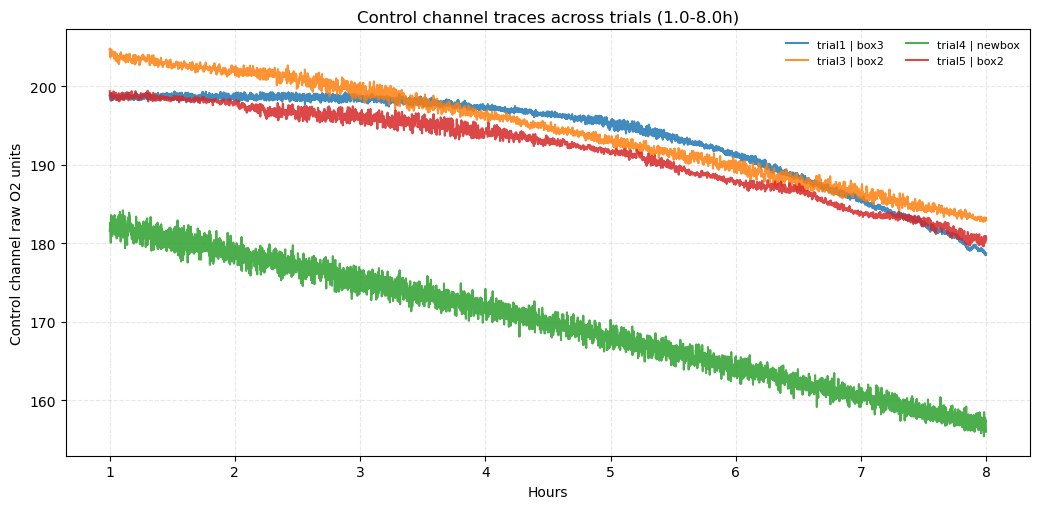

In [15]:
# Control channels overlaid across trials (common 1-8h window).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

window_start_h = 1.0
window_end_h = 8.0

control_long_rows = []
control_summary_rows = []
warnings = []

for run in restricted_runs:
    trial = run.get('trial', 'unknown_trial')
    brick = run.get('brick', 'unknown_brick')
    control_ch = run.get('control', 'Ch1')
    source_path = run.get('control_csv', run.get('csv', None))

    if source_path is None:
        warnings.append(f'{trial}-{brick}: no csv path found')
        continue

    try:
        df = pd.read_csv(source_path)
    except Exception as e:
        warnings.append(f'{trial}-{brick}: failed reading {source_path} ({e})')
        continue

    if 'hours' not in df.columns or control_ch not in df.columns:
        warnings.append(f'{trial}-{brick}: missing hours or {control_ch}')
        continue

    d = df[['hours', control_ch]].dropna().copy()
    d = d[(d['hours'] >= window_start_h) & (d['hours'] <= window_end_h)].copy()
    if len(d) < 5:
        warnings.append(f'{trial}-{brick}: <5 rows in {window_start_h}-{window_end_h}h window')
        continue

    d = d.sort_values('hours').reset_index(drop=True)
    slope = float(np.polyfit(d['hours'].to_numpy(dtype=float), d[control_ch].to_numpy(dtype=float), 1)[0])
    label = f'{trial} | {brick}'

    d['trial'] = trial
    d['brick'] = brick
    d['label'] = label
    d['control_channel'] = control_ch
    d = d.rename(columns={control_ch: 'control_value'})
    control_long_rows.append(d[['hours', 'control_value', 'trial', 'brick', 'label', 'control_channel']])

    control_summary_rows.append({
        'trial': trial,
        'brick': brick,
        'label': label,
        'control_channel': control_ch,
        'n_points': int(len(d)),
        'control_mean': float(d['control_value'].mean()),
        'control_median': float(d['control_value'].median()),
        'control_start': float(d['control_value'].iloc[0]),
        'control_end': float(d['control_value'].iloc[-1]),
        'control_delta_end_minus_start': float(d['control_value'].iloc[-1] - d['control_value'].iloc[0]),
        'control_slope_per_hour': slope,
        'source_csv': str(source_path),
    })

if warnings:
    print('Warnings:')
    for w in warnings:
        print(' -', w)

if not control_summary_rows:
    raise ValueError('No control series available to plot.')

control_long_df = pd.concat(control_long_rows, ignore_index=True)
control_overlay_summary_df = pd.DataFrame(control_summary_rows).sort_values('control_mean', ascending=False).reset_index(drop=True)

print('Control summary (sorted by mean, higher first):')
display(control_overlay_summary_df)

# Determine whether trial4 is the highest by control mean among available runs.
trial4_rows = control_overlay_summary_df[control_overlay_summary_df['trial'].eq('trial4')]
if trial4_rows.empty:
    print('Trial 4 is not present in restricted_runs for this notebook state.')
else:
    trial4_top = bool(control_overlay_summary_df.loc[0, 'trial'] == 'trial4')
    trial4_mean = float(trial4_rows['control_mean'].iloc[0])
    print(f"Trial 4 control mean in {window_start_h}-{window_end_h}h window: {trial4_mean:.3f}")
    print(f"Is Trial 4 the highest control mean? {'YES' if trial4_top else 'NO'}")

# One overlay plot with all control traces.
fig, ax = plt.subplots(figsize=(10.5, 5.2))
for label, g in control_long_df.groupby('label'):
    g = g.sort_values('hours')
    ax.plot(g['hours'], g['control_value'], linewidth=1.5, alpha=0.85, label=label)

ax.set_title(f'Control channel traces across trials ({window_start_h}-{window_end_h}h)')
ax.set_xlabel('Hours')
ax.set_ylabel('Control channel raw O2 units')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Experimental channel summary across the whole night:


,trial,brick,channel,label,n_points,exp_mean,exp_median,exp_min,exp_max,exp_start,exp_end,exp_delta_end_minus_start,exp_slope_per_hour,source_csv
0,trial1,box3,Ch2,trial1 | box3 | Ch2,12101,168.056504,172.930000,126.280000,195.310000,194.950000,126.490000,-68.460000,-10.339702,/Users/oakley/Documents/GitHub/signal_respirom...
1,trial1,box3,Ch3,trial1 | box3 | Ch3,12101,160.115772,159.590000,126.420000,191.950000,191.320000,127.290000,-64.030000,-10.185860,/Users/oakley/Documents/GitHub/signal_respirom...
2,trial1,box3,Ch4,trial1 | box3 | Ch4,12101,165.755144,165.320000,133.700000,195.750000,195.400000,133.750000,-61.650000,-9.491351,/Users/oakley/Documents/GitHub/signal_respirom...
3,trial3,box2,Ch2,trial3 | box2 | Ch2,5041,172.508913,173.350000,147.830000,193.690000,193.410000,147.870000,-45.540000,-6.657990,/Users/oakley/Documents/GitHub/signal_respirom...
4,trial3,box2,Ch3,trial3 | box2 | Ch3,5041,175.501087,175.700000,156.270000,193.810000,192.410000,156.600000,-35.810000,-5.243724,/Users/oakley/Documents/GitHub/signal_respirom...
5,trial3,box2,Ch4,trial3 | box2 | Ch4,5041,171.363595,171.950000,140.500000,198.820000,198.000000,140.500000,-57.500000,-8.432984,/Users/oakley/Documents/GitHub/signal_respirom...
6,trial4,newbox,Ch2,trial4 | newbox | Ch2,5040,166.462122,166.209747,153.113892,181.432709,179.426834,153.728012,-25.698822,-3.638441,/Users/oakley/Documents/GitHub/signal_respirom...
7,trial4,newbox,Ch4,trial4 | newbox | Ch4,5040,169.486934,169.075714,157.533951,184.490097,182.464874,158.166275,-24.298599,-3.355491,/Users/oakley/Documents/GitHub/signal_respirom...
8,trial5,box2,Ch2,trial5 | box2 | Ch2,5041,182.856001,184.370000,166.870000,194.410000,194.220000,167.510000,-26.710000,-3.875585,/Users/oakley/Documents/GitHub/signal_respirom...
9,trial5,box2,Ch4,trial5 | box2 | Ch4,5041,186.123464,187.450000,170.230000,197.820000,196.550000,170.520000,-26.030000,-3.863438,/Users/oakley/Documents/GitHub/signal_respirom...


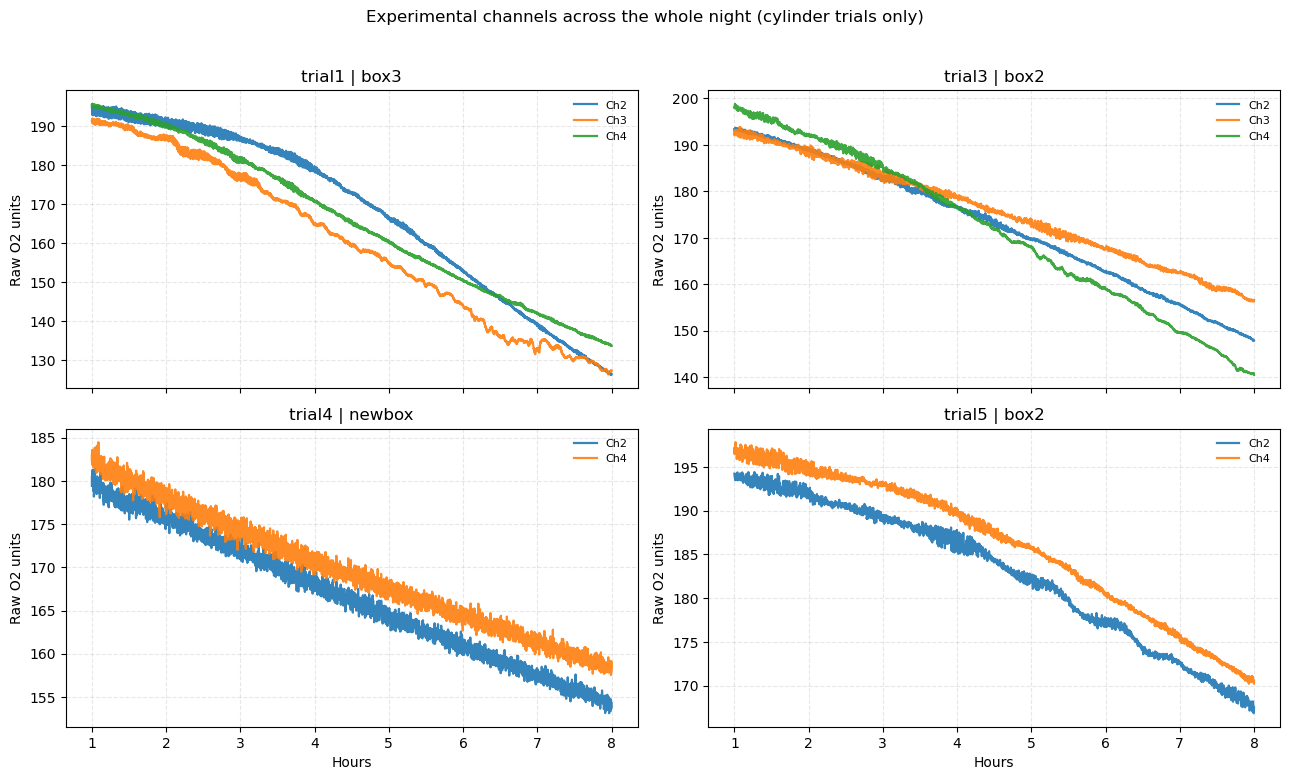

In [16]:
# Experimental channels across the whole night for cylinder trials.
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

whole_night_start_h = 1.0
whole_night_end_h = 8.0

exp_long_rows = []
exp_summary_rows = []
warnings = []

for run in restricted_runs:
    trial = run.get('trial', 'unknown_trial')
    brick = run.get('brick', 'unknown_brick')
    channels = list(run.get('channels', DEFAULT_CHANNELS))
    control_ch = run.get('control', 'Ch1')
    source_path = run.get('csv', None)

    if source_path is None:
        warnings.append(f'{trial}-{brick}: no experimental csv path found')
        continue

    try:
        df = pd.read_csv(source_path)
    except Exception as exc:
        warnings.append(f'{trial}-{brick}: failed reading {source_path} ({exc})')
        continue

    if 'hours' not in df.columns:
        warnings.append(f'{trial}-{brick}: missing hours column')
        continue

    d = df.copy()
    d = d[(d['hours'] >= whole_night_start_h) & (d['hours'] <= whole_night_end_h)].copy()
    if len(d) < 5:
        warnings.append(f'{trial}-{brick}: <5 rows in {whole_night_start_h}-{whole_night_end_h}h window')
        continue

    exp_channels = [ch for ch in channels if ch != control_ch and ch in d.columns]
    if not exp_channels:
        warnings.append(f'{trial}-{brick}: no experimental channels found after excluding control {control_ch}')
        continue

    for ch in exp_channels:
        series = d[['hours', ch]].dropna().sort_values('hours').reset_index(drop=True)
        if len(series) < 5:
            warnings.append(f'{trial}-{brick}-{ch}: <5 non-null points in whole-night window')
            continue

        slope = float(np.polyfit(series['hours'].to_numpy(dtype=float), series[ch].to_numpy(dtype=float), 1)[0])
        label = f'{trial} | {brick} | {ch}'

        series = series.rename(columns={ch: 'channel_value'})
        series['trial'] = trial
        series['brick'] = brick
        series['channel'] = ch
        series['label'] = label
        exp_long_rows.append(series[['hours', 'channel_value', 'trial', 'brick', 'channel', 'label']])

        exp_summary_rows.append({
            'trial': trial,
            'brick': brick,
            'channel': ch,
            'label': label,
            'n_points': int(len(series)),
            'exp_mean': float(series['channel_value'].mean()),
            'exp_median': float(series['channel_value'].median()),
            'exp_min': float(series['channel_value'].min()),
            'exp_max': float(series['channel_value'].max()),
            'exp_start': float(series['channel_value'].iloc[0]),
            'exp_end': float(series['channel_value'].iloc[-1]),
            'exp_delta_end_minus_start': float(series['channel_value'].iloc[-1] - series['channel_value'].iloc[0]),
            'exp_slope_per_hour': slope,
            'source_csv': str(source_path),
        })

if warnings:
    print('Warnings:')
    for w in warnings:
        print(' -', w)

if not exp_summary_rows:
    raise ValueError('No experimental channel series available to plot.')

experimental_channel_long_df = pd.concat(exp_long_rows, ignore_index=True)
experimental_channel_summary_df = pd.DataFrame(exp_summary_rows).sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)

print('Experimental channel summary across the whole night:')
display(experimental_channel_summary_df)

run_keys = experimental_channel_summary_df[['trial', 'brick']].drop_duplicates().reset_index(drop=True)
n_runs = len(run_keys)
n_cols = 2
n_rows = math.ceil(n_runs / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.8 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, (_, key) in zip(axes, run_keys.iterrows()):
    trial = key['trial']
    brick = key['brick']
    run_df = experimental_channel_long_df[
        (experimental_channel_long_df['trial'] == trial)
        & (experimental_channel_long_df['brick'] == brick)
    ].copy()

    for ch, g in run_df.groupby('channel'):
        g = g.sort_values('hours')
        ax.plot(g['hours'], g['channel_value'], linewidth=1.6, alpha=0.9, label=ch)

    ax.set_title(f'{trial} | {brick}')
    ax.set_ylabel('Raw O2 units')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(frameon=False, fontsize=8)

for ax in axes[n_runs:]:
    ax.axis('off')

for ax in axes[-n_cols:]:
    ax.set_xlabel('Hours')

fig.suptitle('Experimental channels across the whole night (cylinder trials only)', y=1.02)
plt.tight_layout()
plt.show()

Experimental minus control summary across the whole night:


,trial,brick,channel,label,n_points,diff_mean,diff_median,diff_min,diff_max,diff_start,diff_end,diff_delta_end_minus_start,diff_slope_per_hour,source_csv
0,trial1,box3,Ch2,trial1 | box3 | Ch2,12101,-25.603724,-23.460000,-52.630000,-3.140000,-3.800000,-52.190000,-48.390000,-7.695392,/Users/oakley/Documents/GitHub/signal_respirom...
1,trial1,box3,Ch3,trial1 | box3 | Ch3,12101,-33.544456,-36.800000,-54.140000,-6.500000,-7.430000,-51.390000,-43.960000,-7.541550,/Users/oakley/Documents/GitHub/signal_respirom...
2,trial1,box3,Ch4,trial1 | box3 | Ch4,12101,-27.905084,-31.110000,-45.620000,-2.510000,-3.350000,-44.930000,-41.580000,-6.847041,/Users/oakley/Documents/GitHub/signal_respirom...
3,trial3,box2,Ch2,trial3 | box2 | Ch2,5041,-21.816765,-21.390000,-35.400000,-9.590000,-11.310000,-35.170000,-23.860000,-3.557097,/Users/oakley/Documents/GitHub/signal_respirom...
4,trial3,box2,Ch3,trial3 | box2 | Ch3,5041,-18.824590,-18.900000,-26.860000,-9.570000,-12.310000,-26.440000,-14.130000,-2.142831,/Users/oakley/Documents/GitHub/signal_respirom...
5,trial3,box2,Ch4,trial3 | box2 | Ch4,5041,-22.962083,-22.750000,-42.690000,-4.750000,-6.720000,-42.540000,-35.820000,-5.332091,/Users/oakley/Documents/GitHub/signal_respirom...
6,trial4,newbox,Ch2,trial4 | newbox | Ch2,5040,-3.242202,-3.246873,-7.009018,0.404358,-2.179871,-2.248428,-0.068557,0.018791,/Users/oakley/Documents/GitHub/signal_respirom...
7,trial4,newbox,Ch4,trial4 | newbox | Ch4,5040,-0.217390,-0.232972,-4.425049,4.291885,0.858169,2.189835,1.331666,0.301741,/Users/oakley/Documents/GitHub/signal_respirom...
8,trial5,box2,Ch2,trial5 | box2 | Ch2,5041,-8.793414,-8.750000,-14.190000,-3.950000,-5.120000,-13.070000,-7.950000,-1.220531,/Users/oakley/Documents/GitHub/signal_respirom...
9,trial5,box2,Ch4,trial5 | box2 | Ch4,5041,-5.525951,-5.570000,-10.630000,-0.610000,-2.790000,-10.060000,-7.270000,-1.208385,/Users/oakley/Documents/GitHub/signal_respirom...


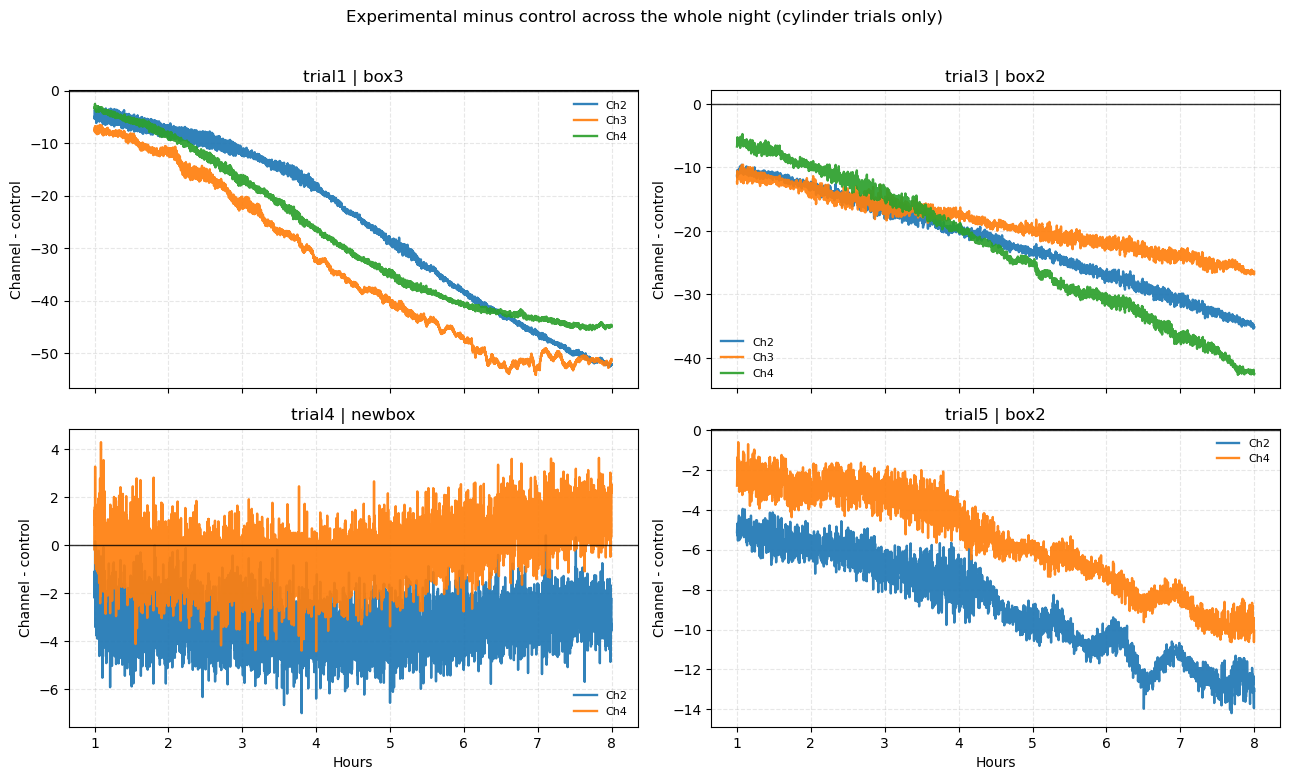

In [17]:
# Experimental minus control across the whole night for cylinder trials.
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

whole_night_start_h = 1.0
whole_night_end_h = 8.0

diff_long_rows = []
diff_summary_rows = []
warnings = []

for run in restricted_runs:
    trial = run.get('trial', 'unknown_trial')
    brick = run.get('brick', 'unknown_brick')
    channels = list(run.get('channels', DEFAULT_CHANNELS))
    control_ch = run.get('control', 'Ch1')
    source_path = run.get('csv', None)

    if source_path is None:
        warnings.append(f'{trial}-{brick}: no experimental csv path found')
        continue

    try:
        df = pd.read_csv(source_path)
    except Exception as exc:
        warnings.append(f'{trial}-{brick}: failed reading {source_path} ({exc})')
        continue

    needed_cols = ['hours', control_ch]
    if any(col not in df.columns for col in needed_cols):
        warnings.append(f'{trial}-{brick}: missing hours or control column {control_ch}')
        continue

    d = df.copy()
    d = d[(d['hours'] >= whole_night_start_h) & (d['hours'] <= whole_night_end_h)].copy()
    if len(d) < 5:
        warnings.append(f'{trial}-{brick}: <5 rows in {whole_night_start_h}-{whole_night_end_h}h window')
        continue

    exp_channels = [ch for ch in channels if ch != control_ch and ch in d.columns]
    if not exp_channels:
        warnings.append(f'{trial}-{brick}: no experimental channels found after excluding control {control_ch}')
        continue

    base = d[['hours', control_ch]].dropna().rename(columns={control_ch: 'control_value'})

    for ch in exp_channels:
        series = d[['hours', ch]].dropna().rename(columns={ch: 'channel_value'})
        merged = base.merge(series, on='hours', how='inner').sort_values('hours').reset_index(drop=True)
        if len(merged) < 5:
            warnings.append(f'{trial}-{brick}-{ch}: <5 aligned channel/control points in whole-night window')
            continue

        merged['channel_minus_control'] = merged['channel_value'] - merged['control_value']
        slope = float(np.polyfit(
            merged['hours'].to_numpy(dtype=float),
            merged['channel_minus_control'].to_numpy(dtype=float),
            1,
        )[0])
        label = f'{trial} | {brick} | {ch}'

        merged['trial'] = trial
        merged['brick'] = brick
        merged['channel'] = ch
        merged['label'] = label
        diff_long_rows.append(
            merged[['hours', 'channel_minus_control', 'control_value', 'channel_value', 'trial', 'brick', 'channel', 'label']]
        )

        diff_summary_rows.append({
            'trial': trial,
            'brick': brick,
            'channel': ch,
            'label': label,
            'n_points': int(len(merged)),
            'diff_mean': float(merged['channel_minus_control'].mean()),
            'diff_median': float(merged['channel_minus_control'].median()),
            'diff_min': float(merged['channel_minus_control'].min()),
            'diff_max': float(merged['channel_minus_control'].max()),
            'diff_start': float(merged['channel_minus_control'].iloc[0]),
            'diff_end': float(merged['channel_minus_control'].iloc[-1]),
            'diff_delta_end_minus_start': float(
                merged['channel_minus_control'].iloc[-1] - merged['channel_minus_control'].iloc[0]
            ),
            'diff_slope_per_hour': slope,
            'source_csv': str(source_path),
        })

if warnings:
    print('Warnings:')
    for w in warnings:
        print(' -', w)

if not diff_summary_rows:
    raise ValueError('No experimental-minus-control series available to plot.')

channel_minus_control_long_df = pd.concat(diff_long_rows, ignore_index=True)
channel_minus_control_summary_df = pd.DataFrame(diff_summary_rows).sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)

print('Experimental minus control summary across the whole night:')
display(channel_minus_control_summary_df)

run_keys = channel_minus_control_summary_df[['trial', 'brick']].drop_duplicates().reset_index(drop=True)
n_runs = len(run_keys)
n_cols = 2
n_rows = math.ceil(n_runs / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.8 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, (_, key) in zip(axes, run_keys.iterrows()):
    trial = key['trial']
    brick = key['brick']
    run_df = channel_minus_control_long_df[
        (channel_minus_control_long_df['trial'] == trial)
        & (channel_minus_control_long_df['brick'] == brick)
    ].copy()

    for ch, g in run_df.groupby('channel'):
        g = g.sort_values('hours')
        ax.plot(g['hours'], g['channel_minus_control'], linewidth=1.7, alpha=0.92, label=ch)

    ax.axhline(0.0, color='black', linewidth=1, alpha=0.8)
    ax.set_title(f'{trial} | {brick}')
    ax.set_ylabel('Channel - control')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(frameon=False, fontsize=8)

for ax in axes[n_runs:]:
    ax.axis('off')

for ax in axes[-n_cols:]:
    ax.set_xlabel('Hours')

fig.suptitle('Experimental minus control across the whole night (cylinder trials only)', y=1.02)
plt.tight_layout()
plt.show()

Early-vs-late slope comparison table:


,trial,brick,channel,unit,slope_control_early,slope_control_late,delta_control_late_minus_early,slope_channel_early,slope_channel_late,delta_channel_late_minus_early,slope_diff_early,slope_diff_late,delta_diff_late_minus_early,abs_ratio_diff_late_over_early,source_csv
0,trial1,box3,Ch2,trial1 | box3 | Ch2,-0.072235,-3.924188,-3.851953,-3.543269,-12.810183,-9.266914,-3.471034,-8.885994,-5.414961,2.560043,/Users/oakley/Documents/GitHub/signal_respirom...
1,trial1,box3,Ch3,trial1 | box3 | Ch3,-0.072235,-3.924188,-3.851953,-7.218301,-10.380868,-3.162567,-7.146066,-6.456680,0.689386,0.903529,/Users/oakley/Documents/GitHub/signal_respirom...
2,trial1,box3,Ch4,trial1 | box3 | Ch4,-0.072235,-3.924188,-3.851953,-6.883880,-9.645258,-2.761378,-6.811645,-5.721069,1.090575,0.839895,/Users/oakley/Documents/GitHub/signal_respirom...
3,trial3,box2,Ch2,trial3 | box2 | Ch2,-2.075839,-3.320396,-1.244557,-5.337681,-7.048210,-1.710529,-3.261842,-3.727814,-0.465972,1.142856,/Users/oakley/Documents/GitHub/signal_respirom...
4,trial3,box2,Ch3,trial3 | box2 | Ch3,-2.075839,-3.320396,-1.244557,-4.700835,-5.424409,-0.723574,-2.624996,-2.104013,0.520983,0.801530,/Users/oakley/Documents/GitHub/signal_respirom...
5,trial3,box2,Ch4,trial3 | box2 | Ch4,-2.075839,-3.320396,-1.244557,-6.277254,-8.892611,-2.615357,-4.201415,-5.572215,-1.370800,1.326271,/Users/oakley/Documents/GitHub/signal_respirom...
6,trial4,newbox,Ch2,trial4 | newbox | Ch2,-3.538689,-3.722899,-0.184210,-3.777969,-3.526591,0.251378,-0.239280,0.196308,0.435587,0.820410,/Users/oakley/Documents/GitHub/signal_respirom...
7,trial4,newbox,Ch4,trial4 | newbox | Ch4,-3.538689,-3.722899,-0.184210,-4.068385,-3.154494,0.913892,-0.529696,0.568405,1.098101,1.073078,/Users/oakley/Documents/GitHub/signal_respirom...
8,trial5,box2,Ch2,trial5 | box2 | Ch2,-1.593864,-3.229775,-1.635912,-2.389653,-4.533569,-2.143916,-0.795789,-1.303794,-0.508004,1.638365,/Users/oakley/Documents/GitHub/signal_respirom...
9,trial5,box2,Ch4,trial5 | box2 | Ch4,-1.593864,-3.229775,-1.635912,-1.999645,-4.640304,-2.640659,-0.405781,-1.410529,-1.004748,3.476082,/Users/oakley/Documents/GitHub/signal_respirom...


Late-minus-early slope summary:


,metric,mean,median
0,delta_control_late_minus_early,-1.892977,-1.440234
1,delta_channel_late_minus_early,-2.385962,-2.379636
2,delta_diff_late_minus_early,-0.492985,-0.015192


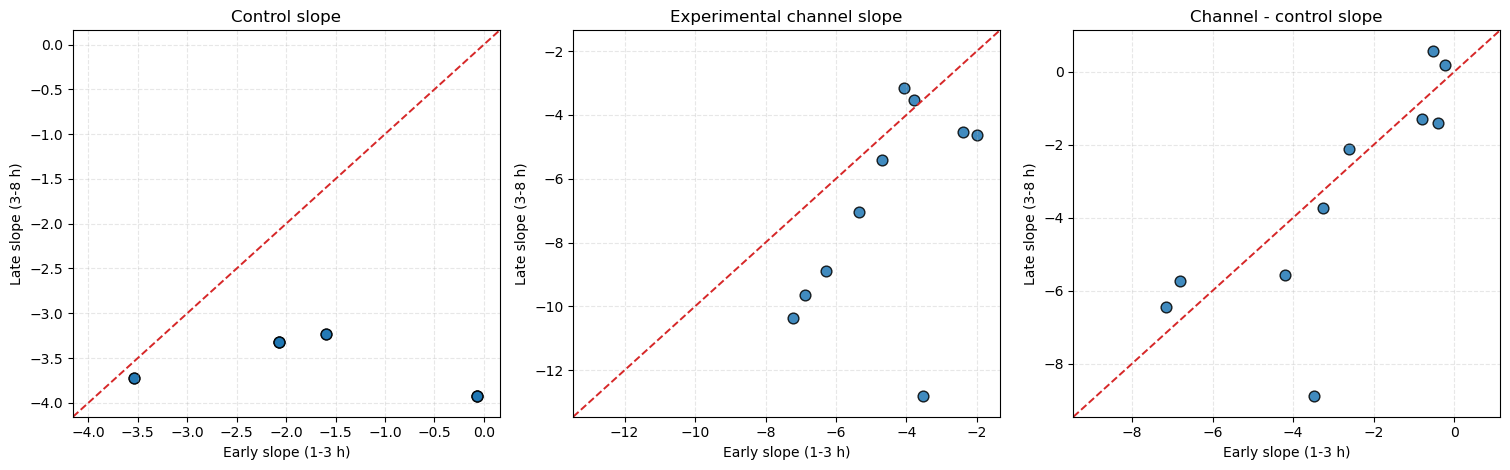

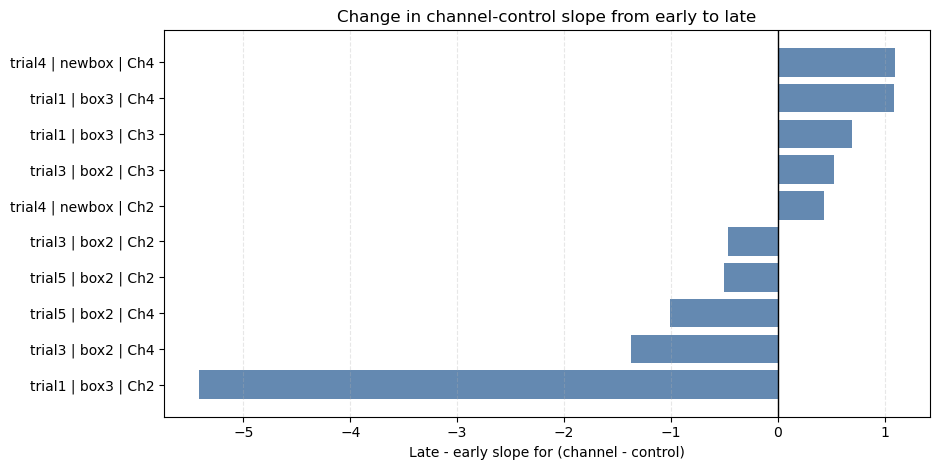

In [18]:
# Early-vs-late slope comparison for control, channel, and channel-control.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not restricted_runs:
    raise ValueError('restricted_runs is empty. Run Cells 2-4 first.')

early_start_h = 1.0
early_end_h = 3.0
late_start_h = 3.0
late_end_h = 8.0
min_points = 5

def fit_slope(df, y_col):
    d = df[['hours', y_col]].dropna()
    if len(d) < min_points:
        return np.nan
    return float(np.polyfit(d['hours'].to_numpy(dtype=float), d[y_col].to_numpy(dtype=float), 1)[0])

rows = []
warnings = []

for run in restricted_runs:
    trial = run.get('trial', 'unknown_trial')
    brick = run.get('brick', 'unknown_brick')
    channels = list(run.get('channels', DEFAULT_CHANNELS))
    control_ch = run.get('control', 'Ch1')
    source_path = run.get('csv', None)

    if source_path is None:
        warnings.append(f'{trial}-{brick}: no csv path found')
        continue

    try:
        df = pd.read_csv(source_path)
    except Exception as exc:
        warnings.append(f'{trial}-{brick}: failed reading {source_path} ({exc})')
        continue

    if 'hours' not in df.columns or control_ch not in df.columns:
        warnings.append(f'{trial}-{brick}: missing hours or control column {control_ch}')
        continue

    exp_channels = [ch for ch in channels if ch != control_ch and ch in df.columns]
    if not exp_channels:
        warnings.append(f'{trial}-{brick}: no experimental channels after excluding control {control_ch}')
        continue

    early = df[(df['hours'] >= early_start_h) & (df['hours'] <= early_end_h)].copy()
    late = df[(df['hours'] >= late_start_h) & (df['hours'] <= late_end_h)].copy()

    for ch in exp_channels:
        e = early[['hours', control_ch, ch]].dropna().copy()
        l = late[['hours', control_ch, ch]].dropna().copy()

        if len(e) < min_points or len(l) < min_points:
            warnings.append(f'{trial}-{brick}-{ch}: insufficient points for early/late fits')
            continue

        e['diff'] = e[ch] - e[control_ch]
        l['diff'] = l[ch] - l[control_ch]

        slope_control_early = fit_slope(e.rename(columns={control_ch: 'y'}), 'y')
        slope_control_late = fit_slope(l.rename(columns={control_ch: 'y'}), 'y')
        slope_channel_early = fit_slope(e.rename(columns={ch: 'y'}), 'y')
        slope_channel_late = fit_slope(l.rename(columns={ch: 'y'}), 'y')
        slope_diff_early = fit_slope(e, 'diff')
        slope_diff_late = fit_slope(l, 'diff')

        rows.append({
            'trial': trial,
            'brick': brick,
            'channel': ch,
            'unit': f'{trial} | {brick} | {ch}',
            'slope_control_early': slope_control_early,
            'slope_control_late': slope_control_late,
            'delta_control_late_minus_early': slope_control_late - slope_control_early,
            'slope_channel_early': slope_channel_early,
            'slope_channel_late': slope_channel_late,
            'delta_channel_late_minus_early': slope_channel_late - slope_channel_early,
            'slope_diff_early': slope_diff_early,
            'slope_diff_late': slope_diff_late,
            'delta_diff_late_minus_early': slope_diff_late - slope_diff_early,
            'abs_ratio_diff_late_over_early': abs(slope_diff_late) / abs(slope_diff_early) if slope_diff_early not in [0, np.nan] else np.nan,
            'source_csv': str(source_path),
        })

slope_compare_df = pd.DataFrame(rows).sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)
if slope_compare_df.empty:
    raise ValueError('No early-vs-late slope comparisons were produced.')

if warnings:
    print('Warnings:')
    for w in warnings:
        print(' -', w)

print('Early-vs-late slope comparison table:')
display(slope_compare_df)

summary_df = slope_compare_df.agg({
    'delta_control_late_minus_early': ['mean', 'median'],
    'delta_channel_late_minus_early': ['mean', 'median'],
    'delta_diff_late_minus_early': ['mean', 'median'],
}).T.reset_index().rename(columns={'index': 'metric'})

print('Late-minus-early slope summary:')
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.8))

pairs = [
    ('slope_control_early', 'slope_control_late', 'Control slope'),
    ('slope_channel_early', 'slope_channel_late', 'Experimental channel slope'),
    ('slope_diff_early', 'slope_diff_late', 'Channel - control slope'),
]

for ax, (xcol, ycol, title) in zip(axes, pairs):
    x = slope_compare_df[xcol].to_numpy(dtype=float)
    y = slope_compare_df[ycol].to_numpy(dtype=float)
    ax.scatter(x, y, s=60, alpha=0.85, color='#1f77b4', edgecolor='black')
    lo = float(min(np.min(x), np.min(y)))
    hi = float(max(np.max(x), np.max(y)))
    pad = 0.06 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', color='#d62728', linewidth=1.4)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Early slope (1-3 h)')
    ax.set_ylabel('Late slope (3-8 h)')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
dplot = slope_compare_df.sort_values('delta_diff_late_minus_early').copy()
ax.barh(np.arange(len(dplot)), dplot['delta_diff_late_minus_early'], color='#4e79a7', alpha=0.88)
ax.axvline(0.0, color='black', linewidth=1)
ax.set_yticks(np.arange(len(dplot)))
ax.set_yticklabels(dplot['unit'])
ax.set_xlabel('Late - early slope for (channel - control)')
ax.set_title('Change in channel-control slope from early to late')
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Merge diagnostics (slope table vs signal rates):


,_merge,n
0,both,10
1,left_only,0
2,right_only,0


Regression-ready rows:


,unit,trial,brick,channel,signal_rate,log10_signal_rate,delta_diff_late_minus_early,late_steepening_index
0,trial4 | newbox | Ch4,trial4,newbox,Ch4,0.051460,-1.288527,1.098101,-1.098101
1,trial4 | newbox | Ch2,trial4,newbox,Ch2,0.087622,-1.057388,0.435587,-0.435587
2,trial5 | box2 | Ch4,trial5,box2,Ch4,0.108451,-0.964768,-1.004748,1.004748
3,trial3 | box2 | Ch2,trial3,box2,Ch2,0.174402,-0.758448,-0.465972,0.465972
4,trial3 | box2 | Ch4,trial3,box2,Ch4,0.233474,-0.631762,-1.370800,1.370800
5,trial5 | box2 | Ch2,trial5,box2,Ch2,0.391549,-0.407214,-0.508004,0.508004
6,trial3 | box2 | Ch3,trial3,box2,Ch3,0.485232,-0.314051,0.520983,-0.520983
7,trial1 | box3 | Ch3,trial1,box3,Ch3,0.981366,-0.008169,0.689386,-0.689386
8,trial1 | box3 | Ch4,trial1,box3,Ch4,4.161491,0.619249,1.090575,-1.090575
9,trial1 | box3 | Ch2,trial1,box3,Ch2,9.745342,0.988797,-5.414961,5.414961


Regression summary:


,model,n,slope,intercept,r,r2,p_value
0,late_steepening ~ signal_rate,10,0.458859,-0.260480,0.737596,0.544048,0.014898
1,late_steepening ~ log10(signal_rate),10,1.281373,0.982762,0.486836,0.237010,0.153582


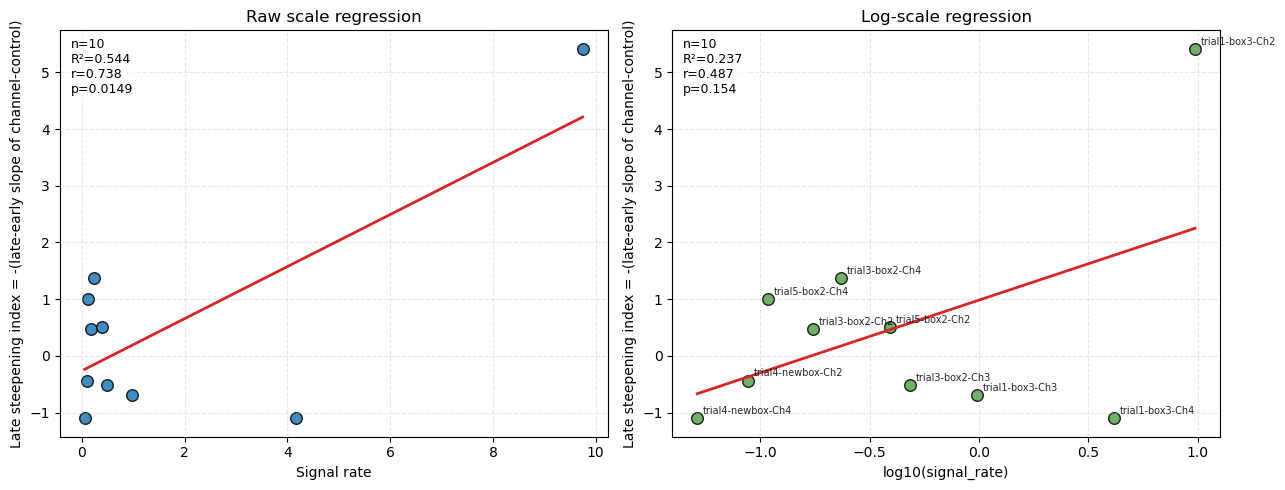

Rank-correlation check (Spearman):


,model,rho,p_value
0,"Spearman(signal_rate, late_steepening)",0.163636,0.651477
1,"Spearman(log10_signal_rate, late_steepening)",0.163636,0.651477


In [19]:
# Regression test: does higher signaling predict stronger late-night channel-control steepening?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

required_vars = ['slope_compare_df', 'OUT_DIR']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f'Run prior cells first. Missing variables: {missing}')

signal_rate_path = OUT_DIR / 'signal_rate_summary.csv'
if not signal_rate_path.exists():
    raise FileNotFoundError(f'Signal-rate table not found: {signal_rate_path}')

signal_df = pd.read_csv(signal_rate_path)
needed_cols = ['trial', 'brick', 'channel', 'signal_rate']
missing_cols = [c for c in needed_cols if c not in signal_df.columns]
if missing_cols:
    raise ValueError(f'signal_rate_summary.csv missing columns: {missing_cols}')

signal_df = signal_df[needed_cols].copy()
signal_df['trial'] = signal_df['trial'].astype(str)
signal_df['brick'] = signal_df['brick'].astype(str)
signal_df['channel'] = signal_df['channel'].astype(str)

reg_df = slope_compare_df.copy()
reg_df['trial'] = reg_df['trial'].astype(str)
reg_df['brick'] = reg_df['brick'].astype(str)
reg_df['channel'] = reg_df['channel'].astype(str)

reg_df = reg_df.merge(signal_df, on=['trial', 'brick', 'channel'], how='left', indicator=True)
print('Merge diagnostics (slope table vs signal rates):')
display(reg_df['_merge'].value_counts(dropna=False).rename_axis('_merge').reset_index(name='n'))

reg_df = reg_df[reg_df['_merge'] == 'both'].copy()
reg_df = reg_df.drop(columns=['_merge'])

# Oxygen-debt style index: larger positive means stronger late-night steepening.
reg_df['late_steepening_index'] = -reg_df['delta_diff_late_minus_early']
reg_df['signal_rate'] = pd.to_numeric(reg_df['signal_rate'], errors='coerce')
reg_df = reg_df.dropna(subset=['signal_rate', 'late_steepening_index'])

# Keep strictly positive rates for log-scale modeling.
reg_df = reg_df[reg_df['signal_rate'] > 0].copy()
if reg_df.empty or len(reg_df) < 3:
    raise ValueError('Too few matched rows for regression (need at least 3 with positive signal_rate).')

reg_df['log10_signal_rate'] = np.log10(reg_df['signal_rate'])

print('Regression-ready rows:')
display(
    reg_df[[
        'unit', 'trial', 'brick', 'channel',
        'signal_rate', 'log10_signal_rate',
        'delta_diff_late_minus_early', 'late_steepening_index',
    ]].sort_values('signal_rate').reset_index(drop=True)
 )

def run_regression(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if _HAVE_SCIPY:
        fit = stats.linregress(x, y)
        return {
            'slope': float(fit.slope),
            'intercept': float(fit.intercept),
            'r': float(fit.rvalue),
            'r2': float(fit.rvalue ** 2),
            'p': float(fit.pvalue),
            'stderr': float(fit.stderr),
        }
    slope, intercept = np.polyfit(x, y, 1)
    yhat = slope * x + intercept
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    r2 = np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan
    return {
        'slope': float(slope),
        'intercept': float(intercept),
        'r': r,
        'r2': float(r2),
        'p': np.nan,
        'stderr': np.nan,
    }

fit_raw = run_regression(reg_df['signal_rate'], reg_df['late_steepening_index'])
fit_log = run_regression(reg_df['log10_signal_rate'], reg_df['late_steepening_index'])

reg_summary_df = pd.DataFrame([
    {
        'model': 'late_steepening ~ signal_rate',
        'n': int(len(reg_df)),
        'slope': fit_raw['slope'],
        'intercept': fit_raw['intercept'],
        'r': fit_raw['r'],
        'r2': fit_raw['r2'],
        'p_value': fit_raw['p'],
    },
    {
        'model': 'late_steepening ~ log10(signal_rate)',
        'n': int(len(reg_df)),
        'slope': fit_log['slope'],
        'intercept': fit_log['intercept'],
        'r': fit_log['r'],
        'r2': fit_log['r2'],
        'p_value': fit_log['p'],
    },
])

print('Regression summary:')
display(reg_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

# Panel 1: raw scale.
x1 = reg_df['signal_rate'].to_numpy(dtype=float)
y = reg_df['late_steepening_index'].to_numpy(dtype=float)
axes[0].scatter(x1, y, s=70, color='#1f77b4', edgecolor='black', alpha=0.85)
x1_line = np.linspace(float(np.min(x1)), float(np.max(x1)), 200)
axes[0].plot(x1_line, fit_raw['slope'] * x1_line + fit_raw['intercept'], color='#d62728', linewidth=2)
axes[0].set_xlabel('Signal rate')
axes[0].set_ylabel('Late steepening index = -(late-early slope of channel-control)')
axes[0].set_title('Raw scale regression')
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].text(
    0.02, 0.98,
    f"n={len(reg_df)}\nR²={fit_raw['r2']:.3f}\nr={fit_raw['r']:.3f}\np={fit_raw['p']:.3g}" if np.isfinite(fit_raw['p']) else f"n={len(reg_df)}\nR²={fit_raw['r2']:.3f}\nr={fit_raw['r']:.3f}\np=NA",
    transform=axes[0].transAxes, va='top', ha='left', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.75, edgecolor='none')
)

# Panel 2: log10 scale.
x2 = reg_df['log10_signal_rate'].to_numpy(dtype=float)
axes[1].scatter(x2, y, s=70, color='#59a14f', edgecolor='black', alpha=0.85)
x2_line = np.linspace(float(np.min(x2)), float(np.max(x2)), 200)
axes[1].plot(x2_line, fit_log['slope'] * x2_line + fit_log['intercept'], color='#d62728', linewidth=2)
axes[1].set_xlabel('log10(signal_rate)')
axes[1].set_ylabel('Late steepening index = -(late-early slope of channel-control)')
axes[1].set_title('Log-scale regression')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].text(
    0.02, 0.98,
    f"n={len(reg_df)}\nR²={fit_log['r2']:.3f}\nr={fit_log['r']:.3f}\np={fit_log['p']:.3g}" if np.isfinite(fit_log['p']) else f"n={len(reg_df)}\nR²={fit_log['r2']:.3f}\nr={fit_log['r']:.3f}\np=NA",
    transform=axes[1].transAxes, va='top', ha='left', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.75, edgecolor='none')
)

for _, row in reg_df.iterrows():
    axes[1].annotate(
        f"{row['trial']}-{row['brick']}-{row['channel']}",
        (row['log10_signal_rate'], row['late_steepening_index']),
        fontsize=7, xytext=(4, 3), textcoords='offset points', alpha=0.85
    )

plt.tight_layout()
plt.show()

if _HAVE_SCIPY:
    rho_raw, p_rho_raw = stats.spearmanr(reg_df['signal_rate'], reg_df['late_steepening_index'])
    rho_log, p_rho_log = stats.spearmanr(reg_df['log10_signal_rate'], reg_df['late_steepening_index'])
    spearman_df = pd.DataFrame([
        {'model': 'Spearman(signal_rate, late_steepening)', 'rho': float(rho_raw), 'p_value': float(p_rho_raw)},
        {'model': 'Spearman(log10_signal_rate, late_steepening)', 'rho': float(rho_log), 'p_value': float(p_rho_log)},
    ])
    print('Rank-correlation check (Spearman):')
    display(spearman_df)
else:
    print('SciPy not available; Spearman rank correlation was skipped.')

Whole-night Trial 4 QC evidence table:


,trial,brick,channel,diff_mean,diff_slope_per_hour,diff_min,diff_max,control_mean,control_slope_per_hour,qc_recommendation,qc_reason,abs_diff_mean,signal_to_background_ratio,trial_is_trial4
0,trial1,box3,Ch2,-25.603724,-7.695392,-52.630000,-3.140000,193.660228,-2.644310,include,none,25.603724,0.132210,False
1,trial1,box3,Ch3,-33.544456,-7.541550,-54.140000,-6.500000,193.660228,-2.644310,include,none,33.544456,0.173213,False
2,trial1,box3,Ch4,-27.905084,-6.847041,-45.620000,-2.510000,193.660228,-2.644310,include,none,27.905084,0.144093,False
3,trial3,box2,Ch2,-21.816765,-3.557097,-35.400000,-9.590000,194.325677,-3.100893,include,none,21.816765,0.112269,False
4,trial3,box2,Ch3,-18.824590,-2.142831,-26.860000,-9.570000,194.325677,-3.100893,include,none,18.824590,0.096871,False
5,trial3,box2,Ch4,-22.962083,-5.332091,-42.690000,-4.750000,194.325677,-3.100893,include,none,22.962083,0.118163,False
6,trial4,newbox,Ch2,-3.242202,0.018791,-7.009018,0.404358,169.704324,-3.657232,exclude,large_correction_whole,3.242202,0.019105,True
7,trial4,newbox,Ch4,-0.217390,0.301741,-4.425049,4.291885,169.704324,-3.657232,exclude,background>=channel (whole); corrected_whole<=...,0.217390,0.001281,True
8,trial5,box2,Ch2,-8.793414,-1.220531,-14.190000,-3.950000,191.649415,-2.655053,include,none,8.793414,0.045883,False
9,trial5,box2,Ch4,-5.525951,-1.208385,-10.630000,-0.610000,191.649415,-2.655053,include,none,5.525951,0.028834,False


Trial-level summary (lower ratio means stronger background dominance):


,trial,n_units,mean_control_level,mean_abs_channel_minus_control,mean_signal_to_background_ratio,frac_qc_exclude
2,trial4,2,169.704324,1.729796,0.010193,1.0
3,trial5,2,191.649415,7.159683,0.037358,0.0
1,trial3,3,194.325677,21.201146,0.109101,0.0
0,trial1,3,193.660228,29.017755,0.149838,0.0


Exact combinational test:


,hypothesis,trial4_mean_ratio,all_units_mean_ratio,n_trial4_units,n_total_units,exact_one_sided_p
0,Trial4 has lower signal/background ratio than ...,0.010193,0.087192,2,10,0.022222


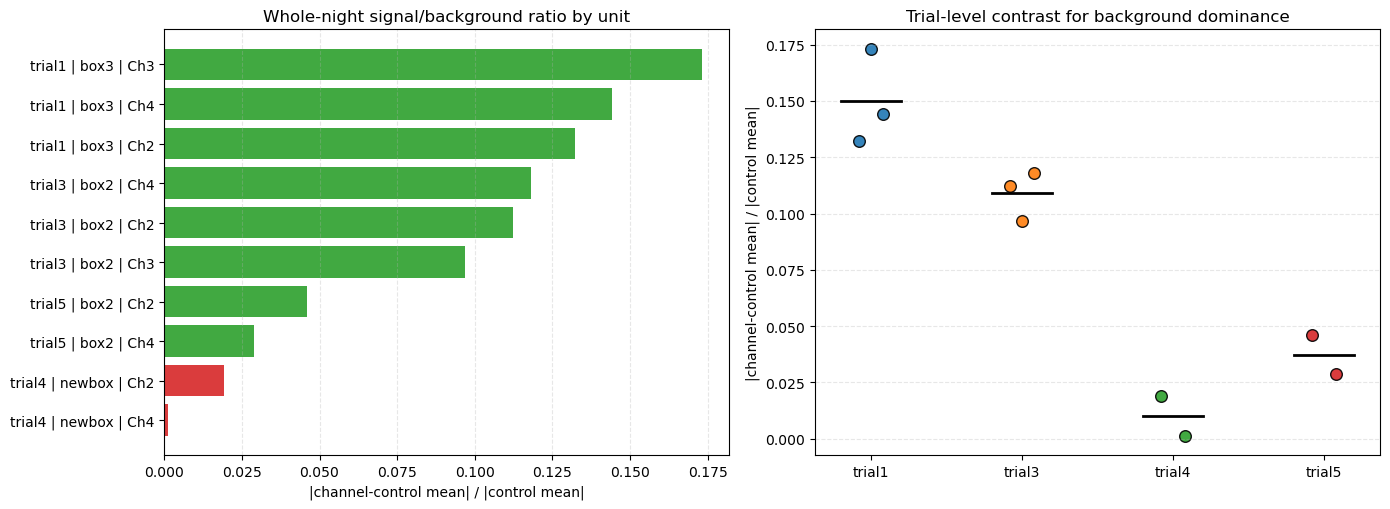

Saved whole-night Trial 4 QC evidence: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/trial4_qc_evidence_wholenight.csv


In [20]:
# Trial 4 QC justification from whole-night evidence only (no sub-night inference).
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_vars = [
    'control_overlay_summary_df',
    'channel_minus_control_summary_df',
    'qc_table_df',
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f'Run prior whole-night cells first. Missing variables: {missing}')

# Assemble per-unit whole-night evidence.
ctrl = control_overlay_summary_df[['trial', 'brick', 'control_mean', 'control_slope_per_hour']].copy()
diff = channel_minus_control_summary_df[[
    'trial', 'brick', 'channel',
    'diff_mean', 'diff_slope_per_hour', 'diff_min', 'diff_max',
]].copy()
qc = qc_table_df[['trial', 'brick', 'channel', 'qc_recommendation', 'qc_reason']].copy()

evidence_df = diff.merge(ctrl, on=['trial', 'brick'], how='left')
evidence_df = evidence_df.merge(qc, on=['trial', 'brick', 'channel'], how='left')

# Background burden proxy: how small is |channel-control| relative to control baseline.
eps = 1e-9
evidence_df['abs_diff_mean'] = np.abs(evidence_df['diff_mean'])
evidence_df['signal_to_background_ratio'] = evidence_df['abs_diff_mean'] / (np.abs(evidence_df['control_mean']) + eps)
evidence_df['trial_is_trial4'] = evidence_df['trial'].eq('trial4')

evidence_df = evidence_df.sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)
print('Whole-night Trial 4 QC evidence table:')
display(evidence_df)

# Trial-level summary for communication.
trial_summary = evidence_df.groupby('trial').agg(
    n_units=('channel', 'size'),
    mean_control_level=('control_mean', 'mean'),
    mean_abs_channel_minus_control=('abs_diff_mean', 'mean'),
    mean_signal_to_background_ratio=('signal_to_background_ratio', 'mean'),
    frac_qc_exclude=('qc_recommendation', lambda x: float(np.mean(x == 'exclude'))),
).reset_index().sort_values('mean_signal_to_background_ratio')

print('Trial-level summary (lower ratio means stronger background dominance):')
display(trial_summary)

# Exact combinational test: is Trial 4 unusually low in signal/background ratio?
vals = evidence_df['signal_to_background_ratio'].to_numpy(dtype=float)
grp = evidence_df['trial_is_trial4'].to_numpy(dtype=bool)
obs = float(np.mean(vals[grp]))
k = int(np.sum(grp))
n = len(vals)

all_means = []
for idxs in itertools.combinations(range(n), k):
    all_means.append(float(np.mean(vals[list(idxs)])))
all_means = np.asarray(all_means, dtype=float)

# One-sided p-value for "Trial 4 ratio is lower than expected".
p_one_sided_low = float(np.mean(all_means <= obs + 1e-12))

test_df = pd.DataFrame([
    {
        'hypothesis': 'Trial4 has lower signal/background ratio than other units',
        'trial4_mean_ratio': obs,
        'all_units_mean_ratio': float(np.mean(vals)),
        'n_trial4_units': k,
        'n_total_units': n,
        'exact_one_sided_p': p_one_sided_low,
    }
])

print('Exact combinational test:')
display(test_df)

# Visual summary: ratio by unit and QC recommendation.
plot_df = evidence_df.copy()
plot_df['unit'] = plot_df['trial'] + ' | ' + plot_df['brick'] + ' | ' + plot_df['channel']
plot_df = plot_df.sort_values('signal_to_background_ratio').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

colors = np.where(plot_df['qc_recommendation'].eq('exclude'), '#d62728', '#2ca02c')
axes[0].barh(np.arange(len(plot_df)), plot_df['signal_to_background_ratio'], color=colors, alpha=0.9)
axes[0].set_yticks(np.arange(len(plot_df)))
axes[0].set_yticklabels(plot_df['unit'])
axes[0].set_xlabel('|channel-control mean| / |control mean|')
axes[0].set_title('Whole-night signal/background ratio by unit')
axes[0].grid(True, axis='x', linestyle='--', alpha=0.3)

trial_order = ['trial1', 'trial3', 'trial4', 'trial5']
for i, tr in enumerate(trial_order):
    d = evidence_df[evidence_df['trial'] == tr]
    if d.empty:
        continue
    jitter = np.linspace(-0.08, 0.08, len(d)) if len(d) > 1 else np.array([0.0])
    axes[1].scatter(np.full(len(d), i) + jitter, d['signal_to_background_ratio'], s=70, alpha=0.9, edgecolor='black')
    m = float(d['signal_to_background_ratio'].mean())
    axes[1].plot([i - 0.2, i + 0.2], [m, m], color='black', linewidth=2)
axes[1].set_xticks(range(len(trial_order)))
axes[1].set_xticklabels(trial_order)
axes[1].set_ylabel('|channel-control mean| / |control mean|')
axes[1].set_title('Trial-level contrast for background dominance')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Save a compact evidence table for reporting.
trial4_qc_evidence_path = OUT_DIR / 'trial4_qc_evidence_wholenight.csv'
evidence_df.to_csv(trial4_qc_evidence_path, index=False)
print(f'Saved whole-night Trial 4 QC evidence: {trial4_qc_evidence_path}')